In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

# Example: Load a CSV file from Google Drive
# Replace 'path/to/your/file.csv' with the actual path to your file
# For example: '/content/drive/MyDrive/my_folder/my_data.csv'
try:
    file_path = '/content/drive/MyDrive/189/project/data/humsavar_dbnsfp53_merged_fast.csv' # CHANGE THIS PATH
    df = pd.read_csv(file_path, na_values="?")
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and Google Drive is mounted.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/MyDrive/189/project/data/humsavar_dbnsfp53_merged_fast.csv


/tmp/ipykernel_1051/1202426911.py:17: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, na_values="?")


,Gene,Entry,FTId,AA_change,Category,dbSNP,Disease,Label,chr,pos,ref,alt,rs_dbSNP,SIFT_score,SIFT_pred,Polyphen2_HDIV_score,Polyphen2_HDIV_pred,CADD_raw,CADD_phred,REVEL_score
0,ALPL,P05186,VAR_025914,p.Thr148Ile,LP/P,rs1376937780,Hypophosphatasia (HOPS) [MIM:146300],Pathogenic,1,21563255.0,C,T,rs1376937780,0.41;0.412;0.394;0.41;.,T;T;T;T;.,0.994;.;.;0.994;.,D;.;.;D;.,4.207815,24.60,0.698;0.698;0.698;0.698;.
1,ALPL,P05186,VAR_013980,p.Arg152His,LB/B,rs149344982,Hypophosphatasia (HOPS) [MIM:146300],Benign,1,21563267.0,G,A,rs149344982,0.428;0.377;0.388;0.428;.,T;T;T;T;.,0.072;.;.;0.072;.,B;.;.;B;.,2.326901,18.24,0.262;0.262;0.262;0.262;.
2,ALPL,P05186,VAR_013980,p.Arg152His,LB/B,rs149344982,Hypophosphatasia (HOPS) [MIM:146300],Benign,1,21563267.0,G,C,rs149344982,0.174;0.169;0.174;0.174;.,T;T;T;T;.,0.972;.;.;0.972;.,D;.;.;D;.,3.939432,23.90,0.770;0.770;0.770;0.770;.
3,ALPL,P05186,VAR_025915,p.Gly162Ser,LP/P,rs760029254,Hypophosphatasia (HOPS) [MIM:146300],Pathogenic,1,21564052.0,G,A,rs760029254,0.0;0.0;0.0;0.0;.,D;D;D;D;.,1.0;.;.;1.0;.,D;.;.;D;.,5.444486,32.00,0.993;0.993;0.993;0.993;.
4,ALPL,P05186,VAR_006153,p.Gly162Val,LP/P,rs121918012,Hypophosphatasia (HOPS) [MIM:146300],Pathogenic,1,21564053.0,G,T,rs121918012,0.0;0.0;0.0;0.0;.,D;D;D;D;.,1.0;.;.;1.0;.,D;.;.;D;.,5.493467,32.00,0.981;0.981;0.981;0.981;.


In [72]:
def clean_score(value):
    """
    Converts semicolon-separated score strings into a single float.
    Example: '0.698;0.698;.;0.698' -> 0.698
    """
    if pd.isna(value):
        return np.nan

    parts = str(value).split(";")

    for p in parts:
        p = p.strip()
        if p != "." and p != "":
            try:
                return float(p)
            except:
                continue

    return np.nan


score_cols = {
    "SIFT_score": "SIFT_score_clean",
    "Polyphen2_HDIV_score": "PolyPhen_score_clean",
    "CADD_raw": "CADD_raw_clean",
    "CADD_phred": "CADD_phred_clean",
    "REVEL_score": "REVEL_score_clean"
}

for old_col, new_col in score_cols.items():
    df[new_col] = df[old_col].apply(clean_score)

df[[
    "SIFT_score_clean",
    "PolyPhen_score_clean",
    "CADD_raw_clean",
    "CADD_phred_clean",
    "REVEL_score_clean"
]].head()

,SIFT_score_clean,PolyPhen_score_clean,CADD_raw_clean,CADD_phred_clean,REVEL_score_clean
0,0.410,0.994,4.207815,24.60,0.698
1,0.428,0.072,2.326901,18.24,0.262
2,0.174,0.972,3.939432,23.90,0.770
3,0.000,1.000,5.444486,32.00,0.993
4,0.000,1.000,5.493467,32.00,0.981


In [73]:

df["y"] = df["Label"].map({
    "Benign": 0,
    "Pathogenic": 1
})

df = df.dropna(subset=["y"])

df["y"].value_counts()


,count
y,
0,68368
1,50639


In [74]:
from google.colab import files

features = [
    "SIFT_score_clean",
    "PolyPhen_score_clean",
    "CADD_raw_clean",
    "CADD_phred_clean",
    "REVEL_score_clean"
]

model_df = df.dropna(subset=features + ["y"]).copy()

X = model_df[features]
y = model_df["y"]

print("Rows used:", len(model_df))
print(y.value_counts())

model_df.to_csv("model_df.csv", index=False)
files.download("model_df.csv")

Rows used: 94318
y
0    56739
1    37579
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X,
    y,
    model_df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 75454
Test size: 18864


In [76]:
from sklearn.metrics import roc_auc_score, average_precision_score

predictor_scores = {
    "SIFT": 1 - model_df.loc[test_idx, "SIFT_score_clean"],
    "PolyPhen-2": model_df.loc[test_idx, "PolyPhen_score_clean"],
    "CADD raw": model_df.loc[test_idx, "CADD_raw_clean"],
    "CADD phred": model_df.loc[test_idx, "CADD_phred_clean"],
    "REVEL": model_df.loc[test_idx, "REVEL_score_clean"]
}

results = []

for name, scores in predictor_scores.items():
    auc = roc_auc_score(y_test, scores)
    ap = average_precision_score(y_test, scores)

    results.append({
        "Model/Predictor": name,
        "ROC-AUC": auc,
        "Average Precision": ap
    })

benchmark_results = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
benchmark_results

,Model/Predictor,ROC-AUC,Average Precision
4,REVEL,0.945537,0.912866
2,CADD raw,0.885845,0.805433
3,CADD phred,0.885835,0.804731
1,PolyPhen-2,0.840298,0.733409
0,SIFT,0.825750,0.733179


In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

threshold_predictions = {
    "SIFT threshold": (model_df.loc[test_idx, "SIFT_score_clean"] < 0.05).astype(int),
    "PolyPhen-2 threshold": (model_df.loc[test_idx, "PolyPhen_score_clean"] > 0.909).astype(int),
    "CADD PHRED threshold": (model_df.loc[test_idx, "CADD_phred_clean"] > 20).astype(int),
    "REVEL threshold": (model_df.loc[test_idx, "REVEL_score_clean"] > 0.5).astype(int)
}

threshold_results = []

for name, preds in threshold_predictions.items():
    threshold_results.append({
        "Predictor": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    })

threshold_results = pd.DataFrame(threshold_results).sort_values("F1", ascending=False)
threshold_results

,Predictor,Accuracy,Precision,Recall,F1
3,REVEL threshold,0.881520,0.847571,0.856706,0.852114
2,CADD PHRED threshold,0.752067,0.626730,0.934007,0.750120
1,PolyPhen-2 threshold,0.763677,0.669137,0.804816,0.730732
0,SIFT threshold,0.713422,0.599173,0.848057,0.702214


In [78]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg.fit(X_train, y_train)

log_reg_probs = log_reg.predict_proba(X_test)[:, 1]
log_reg_preds = log_reg.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, log_reg_probs))
print("Average Precision:", average_precision_score(y_test, log_reg_probs))
print(classification_report(y_test, log_reg_preds))

ROC-AUC: 0.9472494866081018
Average Precision: 0.9145403700324272
              precision    recall  f1-score   support

           0       0.90      0.91      0.90     11348
           1       0.86      0.85      0.85      7516

    accuracy                           0.88     18864
   macro avg       0.88      0.88      0.88     18864
weighted avg       0.88      0.88      0.88     18864



In [79]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]
rf_preds = rf.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, rf_probs))
print("Average Precision:", average_precision_score(y_test, rf_probs))
print(classification_report(y_test, rf_preds))

ROC-AUC: 0.9483653413430037
Average Precision: 0.918803481528822
              precision    recall  f1-score   support

           0       0.92      0.89      0.90     11348
           1       0.84      0.88      0.86      7516

    accuracy                           0.89     18864
   macro avg       0.88      0.89      0.88     18864
weighted avg       0.89      0.89      0.89     18864



In [80]:
ml_results = []

models = {
    "Logistic Regression": log_reg_probs,
    "Random Forest": rf_probs
}

for name, probs in models.items():
    preds = (probs >= 0.5).astype(int)

    ml_results.append({
        "Model/Predictor": name,
        "ROC-AUC": roc_auc_score(y_test, probs),
        "Average Precision": average_precision_score(y_test, probs),
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    })

for name, scores in predictor_scores.items():
    preds = (scores >= 0.5).astype(int)

    ml_results.append({
        "Model/Predictor": name,
        "ROC-AUC": roc_auc_score(y_test, scores),
        "Average Precision": average_precision_score(y_test, scores),
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": np.nan
    })

all_results = pd.DataFrame(ml_results).sort_values("ROC-AUC", ascending=False)
all_results

,Model/Predictor,ROC-AUC,Average Precision,Accuracy,Precision,Recall,F1
1,Random Forest,0.948365,0.918803,0.886079,0.840330,0.881586,0.860464
0,Logistic Regression,0.947249,0.914540,0.882209,0.856642,0.845929,0.851252
6,REVEL,0.945537,0.912866,NaN,NaN,NaN,NaN
4,CADD raw,0.885845,0.805433,NaN,NaN,NaN,NaN
5,CADD phred,0.885835,0.804731,NaN,NaN,NaN,NaN
3,PolyPhen-2,0.840298,0.733409,NaN,NaN,NaN,NaN
2,SIFT,0.825750,0.733179,NaN,NaN,NaN,NaN


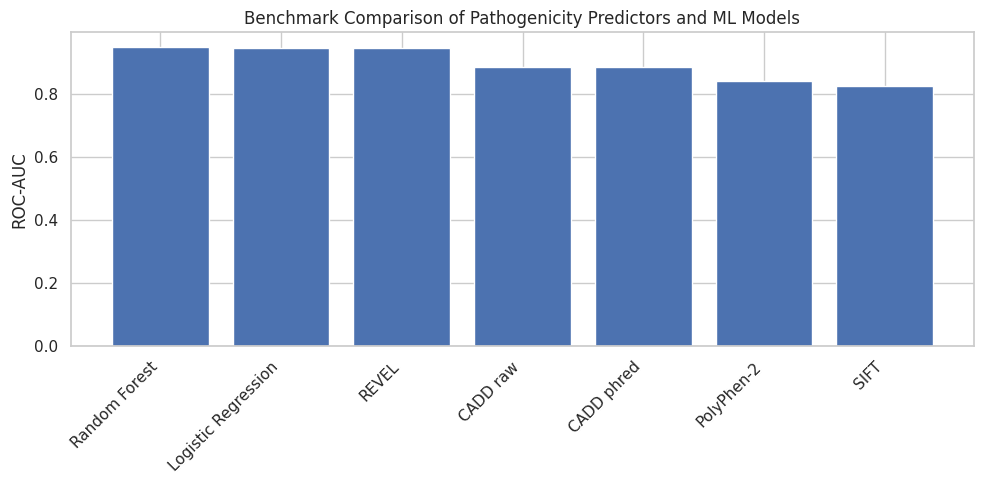

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(all_results["Model/Predictor"], all_results["ROC-AUC"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC-AUC")
plt.title("Benchmark Comparison of Pathogenicity Predictors and ML Models")
plt.tight_layout()
plt.show()

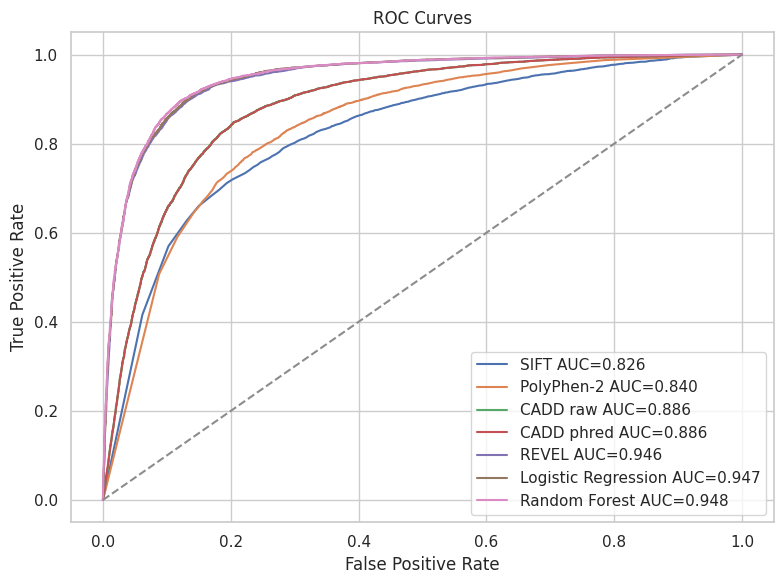

In [82]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

# Existing predictors
for name, scores in predictor_scores.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

# ML models
for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
failure_df = model_df.loc[test_idx].copy()

failure_df["SIFT_score_for_auc"] = 1 - failure_df["SIFT_score_clean"]
failure_df["PolyPhen_score_for_auc"] = failure_df["PolyPhen_score_clean"]
failure_df["CADD_phred_score_for_auc"] = failure_df["CADD_phred_clean"]
failure_df["REVEL_score_for_auc"] = failure_df["REVEL_score_clean"]

failure_df["RF_prob_pathogenic"] = rf_probs
failure_df["LogReg_prob_pathogenic"] = log_reg_probs

failure_df.head()

,Gene,Entry,FTId,AA_change,Category,dbSNP,Disease,Label,chr,pos,ref,alt,rs_dbSNP,SIFT_score,SIFT_pred,Polyphen2_HDIV_score,Polyphen2_HDIV_pred,CADD_raw,CADD_phred,REVEL_score,SIFT_score_clean,PolyPhen_score_clean,CADD_raw_clean,CADD_phred_clean,REVEL_score_clean,y,SIFT_score_for_auc,PolyPhen_score_for_auc,CADD_phred_score_for_auc,REVEL_score_for_auc,RF_prob_pathogenic,LogReg_prob_pathogenic
60248,SH3BP4,Q9P0V3,VAR_030330,p.Met155Thr,LB/B,rs3731644,-,Benign,2,235041233.0,T,C,rs3731644,0.597;0.597;0.597;.;0.831;.;.;.,T;T;T;.;T;.;.;.,0.0;0.0;0.0;0.0;.;0.0;0.0;0.0,B;B;B;B;.;B;B;B,-0.022073,0.984,0.032;0.032;0.032;.;0.032;.;.;.,0.597,0.000,-0.022073,0.984,0.032,0,0.403,0.000,0.984,0.032,0.007871,0.017644
82901,SPEF2,Q9C093,VAR_051377,p.Ala934Pro,LB/B,rs13170390,-,Benign,5,35709082.0,G,A,rs13170390,0.73;.;0.677;.;0.725,T;.;T;.;T,0.0;.;0.0;.;0.02,B;.;B;.;B,-1.101958,0.017,0.013;.;0.013;.;0.013,0.730,0.000,-1.101958,0.017,0.013,0,0.270,0.000,0.017,0.013,0.007623,0.013670
103918,TJP2,Q9UDY2,VAR_030798,p.Asp482Glu,LB/B,rs2309428,-,Benign,9,69228107.0,C,G,rs2309428,.;.;.;.;.;.;1.0;1.0;.;.;.;.;.;1.0;.;0.988;.,.;.;.;.;.;.;T;T;.;.;.;.;.;T;.;T;.,.;.;.;.;.;.;0.0;0.0;.;.;.;.;.;.;.;.;.,.;.;.;.;.;.;B;B;.;.;.;.;.;.;.;.;.,0.359528,3.936,.;.;.;.;.;.;0.014;0.014;.;.;.;.;.;0.014;.;0.014;.,1.000,0.000,0.359528,3.936,0.014,0,0.000,0.000,3.936,0.014,0.001751,0.021623
88156,ARG1,P05089,VAR_015594,p.Ile11Thr,LP/P,rs28941474,Argininemia (ARGIN) [MIM:207800],Pathogenic,6,131573314.0,T,C,rs28941474,.;0.001;.;0.001;.;.;.;.;.;.,.;D;.;D;.;.;.;.;.;.,.;0.994;.;0.992;.;.;.;.;.;.,.;D;.;D;.;.;.;.;.;.,4.337620,25.000,.;0.807;.;0.807;.;.;.;.;.;.,0.001,0.994,4.337620,25.000,0.807,1,0.999,0.994,25.000,0.807,0.899989,0.873462
20308,HMBS,P08397,VAR_025564,p.Glu86Val,LP/P,rs150763621,Acute intermittent porphyria (AIP) [MIM:176000],Pathogenic,11,119089263.0,A,T,rs150763621,.;.;.;.;.;.;0.199;0.204;.;.;.;.;0.276;.;.;0.23...,.;.;.;.;.;.;T;T;.;.;.;.;T;.;.;T;T;.;.;T;T;.,.;.;.;0.996;.;.;0.999;.;.;.;.;.;.;.;.;.;0.995;...,.;.;.;D;.;.;D;.;.;.;.;.;.;.;.;.;D;.;.;.;D;D,4.992618,27.900,.;.;.;.;.;0.899;0.899;0.899;.;.;.;.;0.899;.;0....,0.199,0.996,4.992618,27.900,0.899,1,0.801,0.996,27.900,0.899,0.902066,0.945025


In [84]:
failure_df["SIFT_pred_binary"] = (failure_df["SIFT_score_clean"] < 0.05).astype(int)
failure_df["PolyPhen_pred_binary"] = (failure_df["PolyPhen_score_clean"] > 0.909).astype(int)
failure_df["CADD_pred_binary"] = (failure_df["CADD_phred_clean"] > 20).astype(int)
failure_df["REVEL_pred_binary"] = (failure_df["REVEL_score_clean"] > 0.5).astype(int)
failure_df["RF_pred_binary"] = (failure_df["RF_prob_pathogenic"] >= 0.5).astype(int)

failure_df["SIFT_failed"] = failure_df["SIFT_pred_binary"] != failure_df["y"]
failure_df["PolyPhen_failed"] = failure_df["PolyPhen_pred_binary"] != failure_df["y"]
failure_df["CADD_failed"] = failure_df["CADD_pred_binary"] != failure_df["y"]
failure_df["REVEL_failed"] = failure_df["REVEL_pred_binary"] != failure_df["y"]
failure_df["RF_failed"] = failure_df["RF_pred_binary"] != failure_df["y"]

failure_df[[
    "Gene",
    "AA_change",
    "Label",
    "SIFT_failed",
    "PolyPhen_failed",
    "CADD_failed",
    "REVEL_failed",
    "RF_failed"
]].head()

,Gene,AA_change,Label,SIFT_failed,PolyPhen_failed,CADD_failed,REVEL_failed,RF_failed
60248,SH3BP4,p.Met155Thr,Benign,False,False,False,False,False
82901,SPEF2,p.Ala934Pro,Benign,False,False,False,False,False
103918,TJP2,p.Asp482Glu,Benign,False,False,False,False,False
88156,ARG1,p.Ile11Thr,Pathogenic,False,False,False,False,False
20308,HMBS,p.Glu86Val,Pathogenic,True,False,False,False,False


In [85]:
failure_cols = [
    "SIFT_failed",
    "PolyPhen_failed",
    "CADD_failed",
    "REVEL_failed"
]

failure_df["num_predictors_failed"] = failure_df[failure_cols].sum(axis=1)

hard_cases = failure_df.sort_values("num_predictors_failed", ascending=False)

hard_cases[[
    "Gene",
    "AA_change",
    "Label",
    "Disease",
    "SIFT_score_clean",
    "PolyPhen_score_clean",
    "CADD_phred_clean",
    "REVEL_score_clean",
    "num_predictors_failed"
]].head(20)

,Gene,AA_change,Label,Disease,SIFT_score_clean,PolyPhen_score_clean,CADD_phred_clean,REVEL_score_clean,num_predictors_failed
94413,HOXA4,p.Thr251Pro,Benign,-,0.003,0.980,23.20,0.651,4
96363,ABCB4,p.Arg788Gln,Benign,Gallbladder disease 1 (GBD1) [MIM:600803],0.000,0.989,24.40,0.686,4
2997,USH2A,p.Arg2460His,Pathogenic,Retinitis pigmentosa 39 (RP39) [MIM:613809],0.092,0.681,17.89,0.217,4
41071,ALDOA,p.Glu82Gln,Benign,-,0.000,0.998,33.00,0.746,4
15138,HBB,p.Lys133Asn,Benign,-,0.000,0.999,22.30,0.871,4
33969,CHRNA5,p.Val134Ile,Benign,-,0.000,1.000,26.90,0.803,4
60796,PROC,p.Ala178Pro,Pathogenic,"Thrombophilia due to protein C deficiency, aut...",1.000,0.006,0.01,0.208,4
32724,SERPINA1,p.Ser354Phe,Benign,-,0.001,1.000,25.10,0.821,4
92254,POU6F2,p.Glu639Lys,Benign,-,0.015,0.980,32.00,0.738,4
42516,TP53,p.Pro309Ser,Pathogenic,Li-Fraumeni syndrome (LFS) [MIM:151623],0.122,0.079,17.37,0.443,4


In [86]:
gene_failure = (
    failure_df
    .groupby("Gene")
    .agg(
        total_variants=("Gene", "count"),
        avg_predictors_failed=("num_predictors_failed", "mean"),
        variants_with_any_failure=("num_predictors_failed", lambda x: (x > 0).sum())
    )
    .reset_index()
)

gene_failure["any_failure_rate"] = (
    gene_failure["variants_with_any_failure"] / gene_failure["total_variants"]
)

gene_failure = gene_failure[gene_failure["total_variants"] >= 5]

gene_failure.sort_values(
    ["any_failure_rate", "avg_predictors_failed", "total_variants"],
    ascending=False
).head(20)

,Gene,total_variants,avg_predictors_failed,variants_with_any_failure,any_failure_rate
4435,PROC,8,3.750000,8,1.0
4463,PRSS1,6,3.166667,6,1.0
1977,FGA,6,3.000000,6,1.0
1561,DNASE1,5,3.000000,5,1.0
2349,GRM8,5,2.800000,5,1.0
247,ALDOA,5,2.600000,5,1.0
1557,DNAJC13,7,2.571429,7,1.0
5265,SMG1,7,2.571429,7,1.0
2416,HBD,9,2.444444,9,1.0
567,BCR,5,2.400000,5,1.0


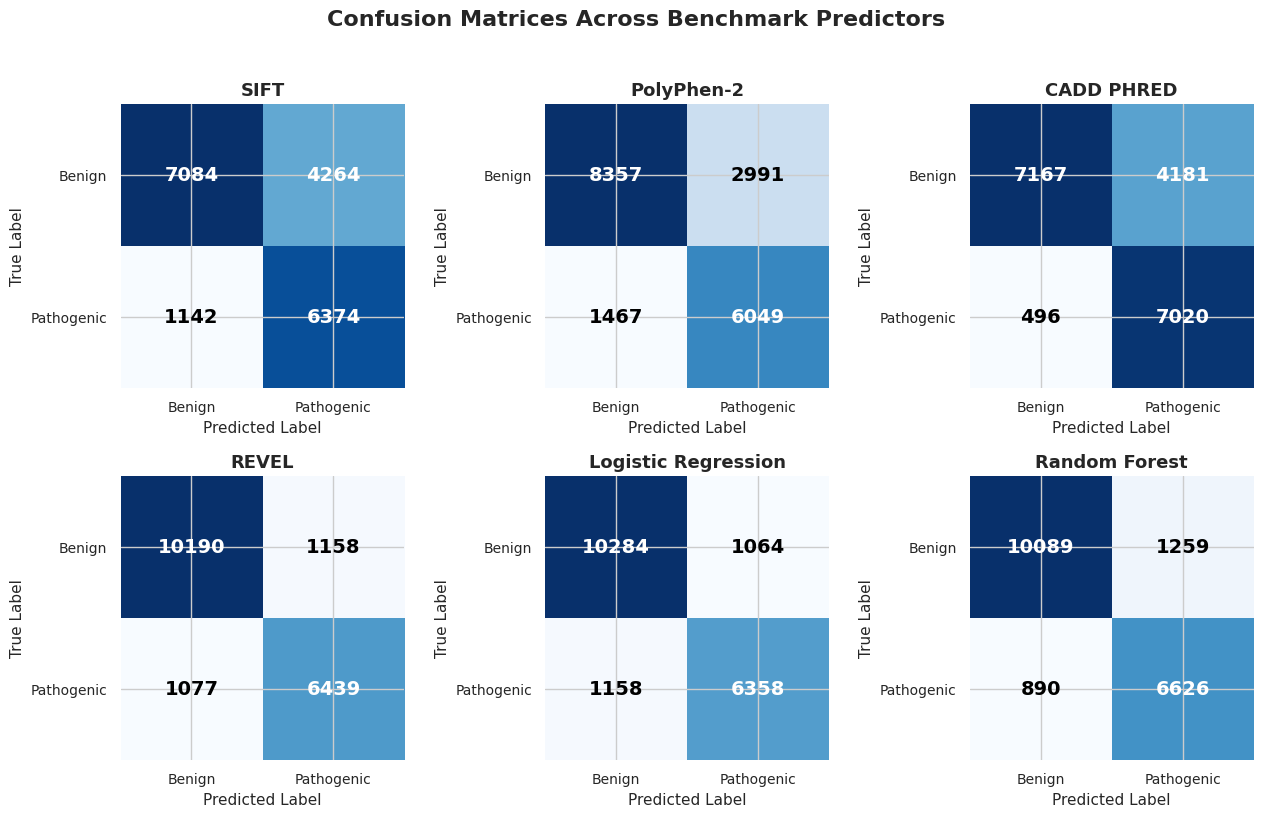

In [87]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Create binary predictions for all benchmark methods
benchmark_binary_preds = {
    "SIFT": (failure_df["SIFT_score_clean"] < 0.05).astype(int),
    "PolyPhen-2": (failure_df["PolyPhen_score_clean"] > 0.909).astype(int),
    "CADD PHRED": (failure_df["CADD_phred_clean"] > 20).astype(int),
    "REVEL": (failure_df["REVEL_score_clean"] > 0.5).astype(int),
    "Logistic Regression": (failure_df["LogReg_prob_pathogenic"] >= 0.5).astype(int),
    "Random Forest": (failure_df["RF_prob_pathogenic"] >= 0.5).astype(int)
}

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, benchmark_binary_preds.items()):
    cm = confusion_matrix(y_test, preds)

    im = ax.imshow(cm, cmap="Blues")

    # Add numbers inside each box
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]

            # Make text readable depending on background color
            text_color = "white" if value > cm.max() / 2 else "black"

            ax.text(
                j,
                i,
                str(value),
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color=text_color
            )

    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Benign", "Pathogenic"], fontsize=10)
    ax.set_yticklabels(["Benign", "Pathogenic"], fontsize=10)

    # Remove unnecessary borders
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle(
    "Confusion Matrices Across Benchmark Predictors",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_rows = []

# Probability/score-based models for ROC-AUC and PR-AUC
score_based_outputs = {
    "SIFT": 1 - failure_df["SIFT_score_clean"],
    "PolyPhen-2": failure_df["PolyPhen_score_clean"],
    "CADD PHRED": failure_df["CADD_phred_clean"],
    "REVEL": failure_df["REVEL_score_clean"],
    "Logistic Regression": failure_df["LogReg_prob_pathogenic"],
    "Random Forest": failure_df["RF_prob_pathogenic"]
}

for name in benchmark_binary_preds.keys():
    preds = benchmark_binary_preds[name]
    scores = score_based_outputs[name]

    comparison_rows.append({
        "Model/Predictor": name,
        "ROC-AUC": roc_auc_score(y_test, scores),
        "PR-AUC": average_precision_score(y_test, scores),
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "False Positives": confusion_matrix(y_test, preds)[0, 1],
        "False Negatives": confusion_matrix(y_test, preds)[1, 0]
    })

benchmark_table = pd.DataFrame(comparison_rows)
benchmark_table = benchmark_table.sort_values("ROC-AUC", ascending=False)

benchmark_table

,Model/Predictor,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1,False Positives,False Negatives
5,Random Forest,0.948365,0.918803,0.886079,0.840330,0.881586,0.860464,1259,890
4,Logistic Regression,0.947249,0.914540,0.882209,0.856642,0.845929,0.851252,1064,1158
3,REVEL,0.945537,0.912866,0.881520,0.847571,0.856706,0.852114,1158,1077
2,CADD PHRED,0.885835,0.804731,0.752067,0.626730,0.934007,0.750120,4181,496
1,PolyPhen-2,0.840298,0.733409,0.763677,0.669137,0.804816,0.730732,2991,1467
0,SIFT,0.825750,0.733179,0.713422,0.599173,0.848057,0.702214,4264,1142


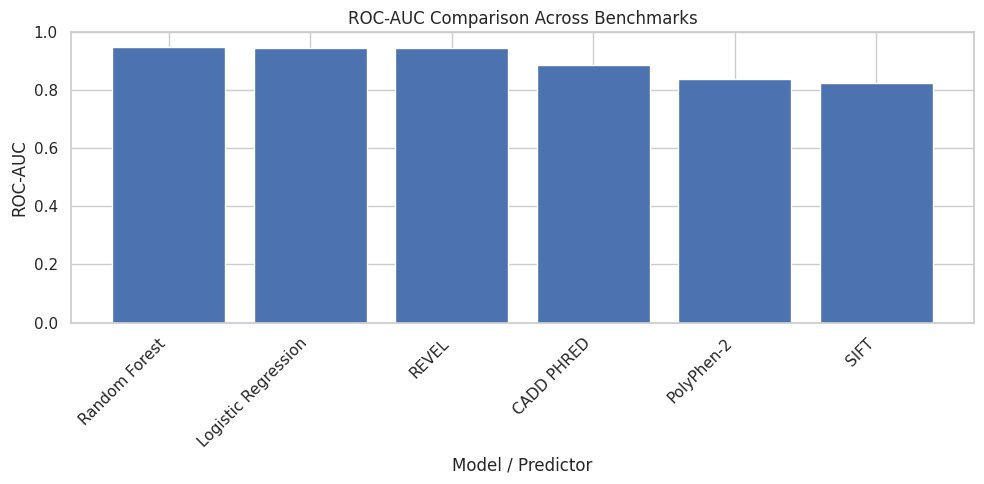

In [89]:
plt.figure(figsize=(10, 5))

plt.bar(
    benchmark_table["Model/Predictor"],
    benchmark_table["ROC-AUC"]
)

plt.ylabel("ROC-AUC")
plt.xlabel("Model / Predictor")
plt.title("ROC-AUC Comparison Across Benchmarks")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

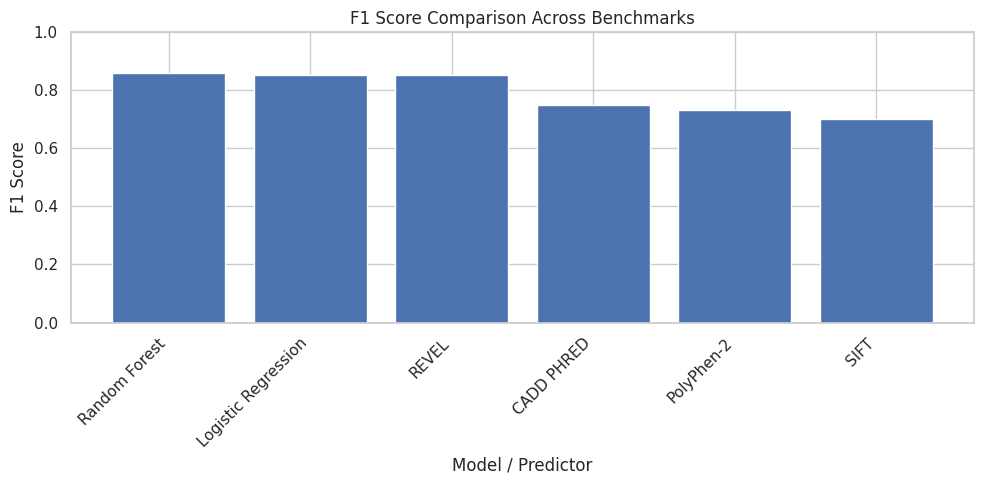

In [90]:
plt.figure(figsize=(10, 5))

plt.bar(
    benchmark_table["Model/Predictor"],
    benchmark_table["F1"]
)

plt.ylabel("F1 Score")
plt.xlabel("Model / Predictor")
plt.title("F1 Score Comparison Across Benchmarks")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

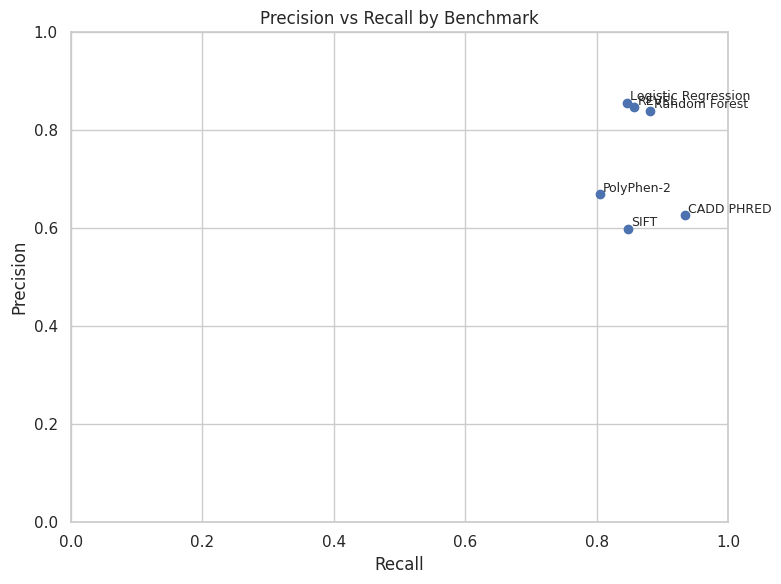

In [91]:
plt.figure(figsize=(8, 6))

plt.scatter(
    benchmark_table["Recall"],
    benchmark_table["Precision"]
)

for _, row in benchmark_table.iterrows():
    plt.text(
        row["Recall"] + 0.005,
        row["Precision"] + 0.005,
        row["Model/Predictor"],
        fontsize=9
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall by Benchmark")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

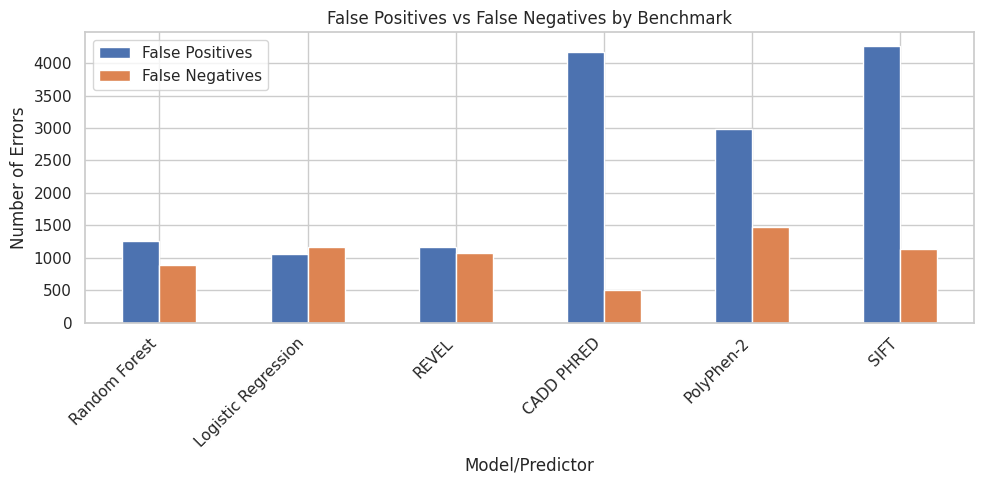

In [92]:
error_counts = benchmark_table[[
    "Model/Predictor",
    "False Positives",
    "False Negatives"
]].copy()

error_counts.plot(
    x="Model/Predictor",
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Number of Errors")
plt.title("False Positives vs False Negatives by Benchmark")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

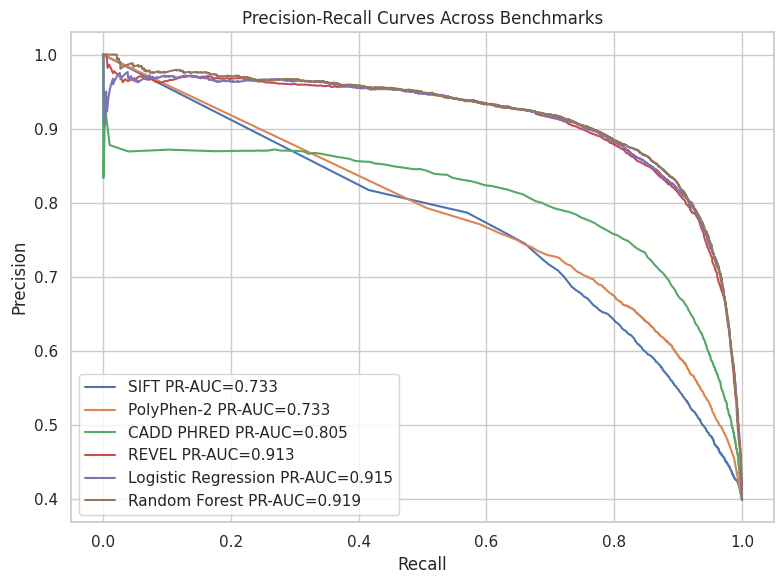

In [93]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))

for name, scores in score_based_outputs.items():
    precision, recall, _ = precision_recall_curve(y_test, scores)
    pr_auc = average_precision_score(y_test, scores)

    plt.plot(recall, precision, label=f"{name} PR-AUC={pr_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves Across Benchmarks")
plt.legend()
plt.tight_layout()
plt.show()

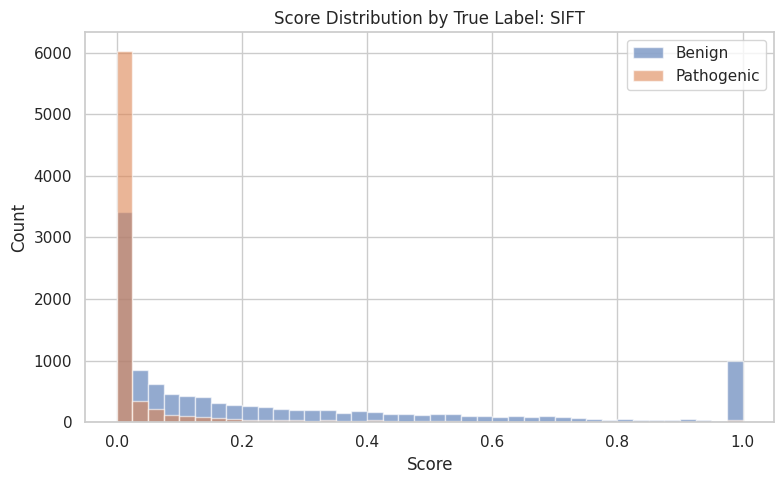

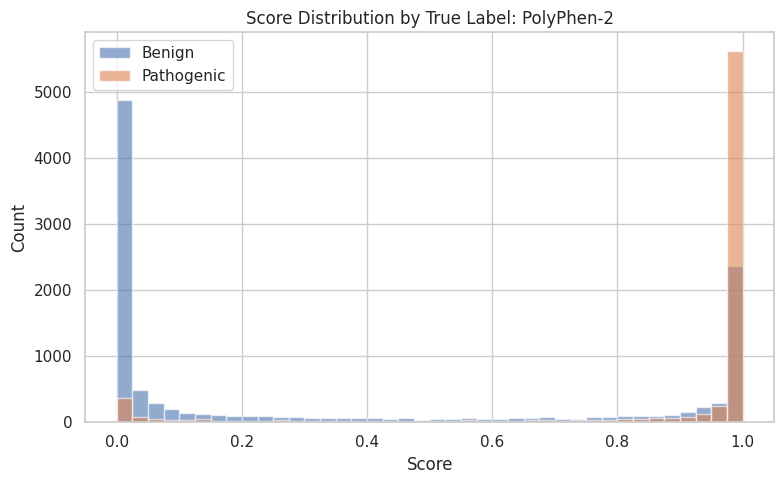

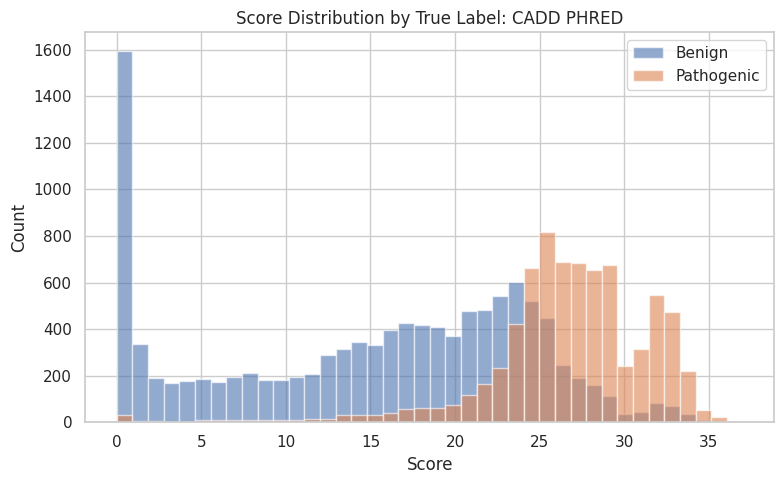

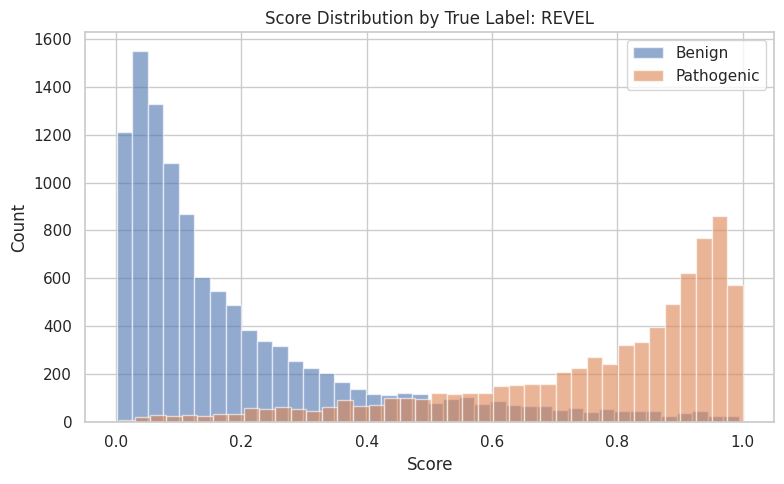

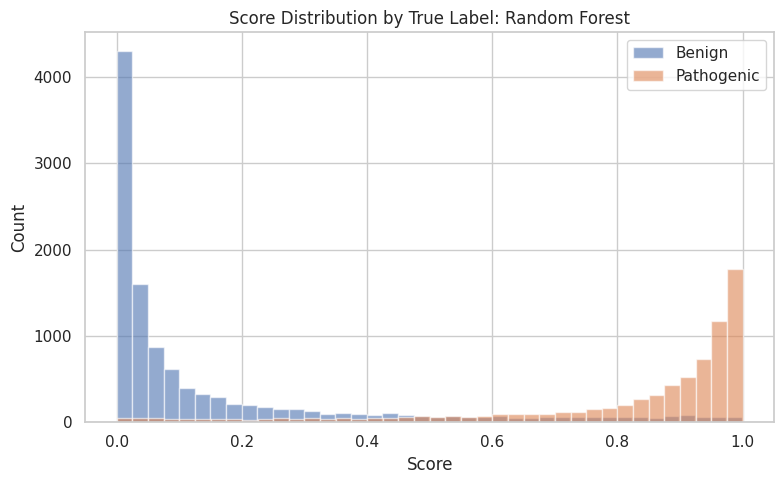

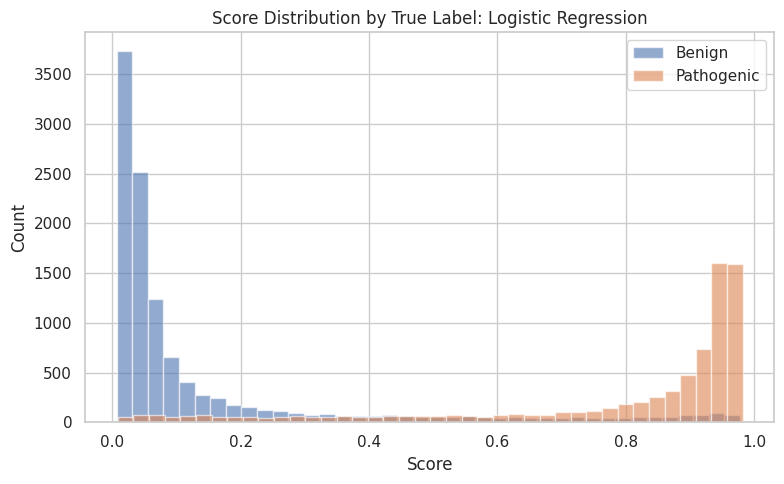

In [94]:
score_columns_for_plot = {
    "SIFT": "SIFT_score_clean",
    "PolyPhen-2": "PolyPhen_score_clean",
    "CADD PHRED": "CADD_phred_clean",
    "REVEL": "REVEL_score_clean",
    "Random Forest": "RF_prob_pathogenic",
    "Logistic Regression": "LogReg_prob_pathogenic"
}

for name, col in score_columns_for_plot.items():
    plt.figure(figsize=(8, 5))

    plt.hist(
        failure_df[failure_df["y"] == 0][col],
        bins=40,
        alpha=0.6,
        label="Benign"
    )

    plt.hist(
        failure_df[failure_df["y"] == 1][col],
        bins=40,
        alpha=0.6,
        label="Pathogenic"
    )

    plt.xlabel("Score")
    plt.ylabel("Count")
    plt.title(f"Score Distribution by True Label: {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

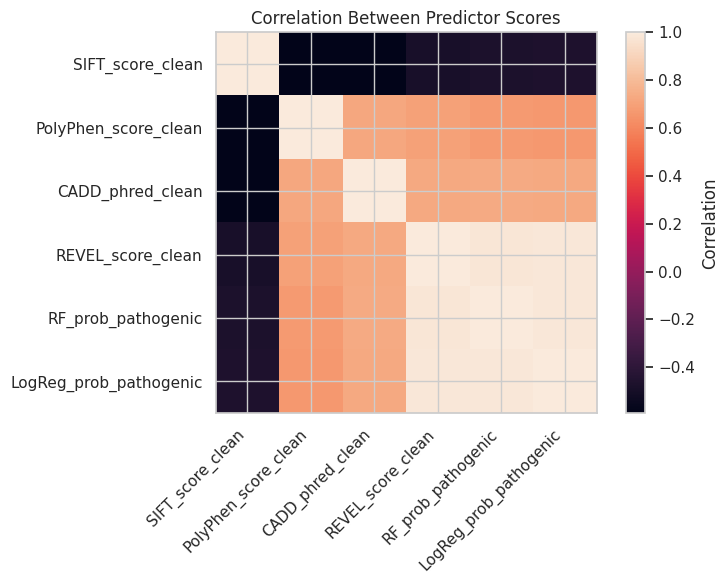

In [95]:
corr_cols = [
    "SIFT_score_clean",
    "PolyPhen_score_clean",
    "CADD_phred_clean",
    "REVEL_score_clean",
    "RF_prob_pathogenic",
    "LogReg_prob_pathogenic"
]

corr_matrix = failure_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix)
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_cols)),
    corr_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_cols)),
    corr_cols
)

plt.title("Correlation Between Predictor Scores")
plt.tight_layout()
plt.show()

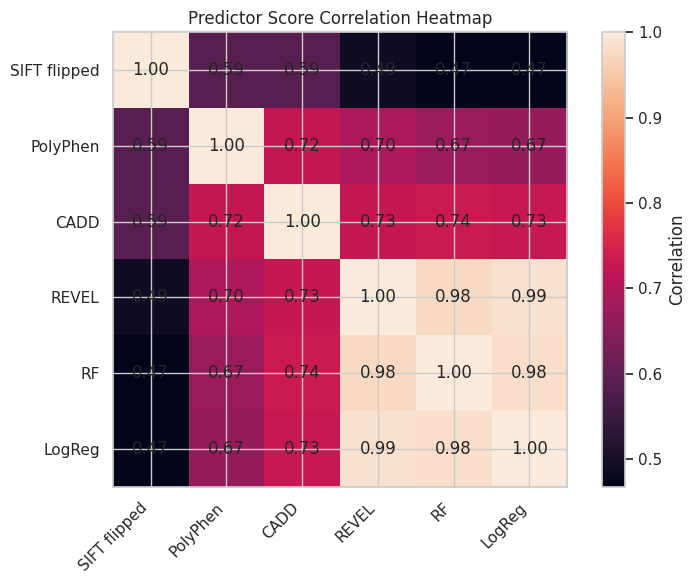

In [96]:
failure_df["SIFT_flipped"] = 1 - failure_df["SIFT_score_clean"]

corr_cols_flipped = [
    "SIFT_flipped",
    "PolyPhen_score_clean",
    "CADD_phred_clean",
    "REVEL_score_clean",
    "RF_prob_pathogenic",
    "LogReg_prob_pathogenic"
]

corr_matrix_flipped = failure_df[corr_cols_flipped].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix_flipped)
plt.colorbar(label="Correlation")

for i in range(len(corr_cols_flipped)):
    for j in range(len(corr_cols_flipped)):
        plt.text(
            j,
            i,
            f"{corr_matrix_flipped.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.xticks(
    range(len(corr_cols_flipped)),
    ["SIFT flipped", "PolyPhen", "CADD", "REVEL", "RF", "LogReg"],
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_cols_flipped)),
    ["SIFT flipped", "PolyPhen", "CADD", "REVEL", "RF", "LogReg"]
)

plt.title("Predictor Score Correlation Heatmap")
plt.tight_layout()
plt.show()

In [97]:
rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance

,Feature,Importance
4,REVEL_score_clean,0.527637
2,CADD_raw_clean,0.229800
3,CADD_phred_clean,0.139532
1,PolyPhen_score_clean,0.060623
0,SIFT_score_clean,0.042408


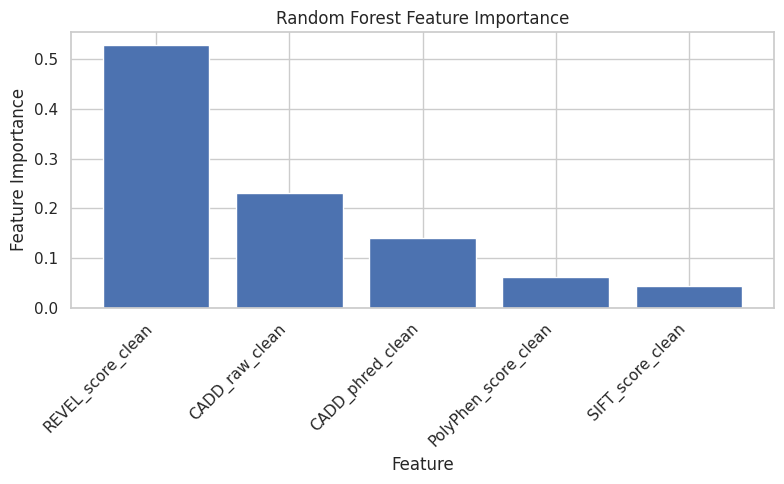

In [98]:
plt.figure(figsize=(8, 5))

plt.bar(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.ylabel("Feature Importance")
plt.xlabel("Feature")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

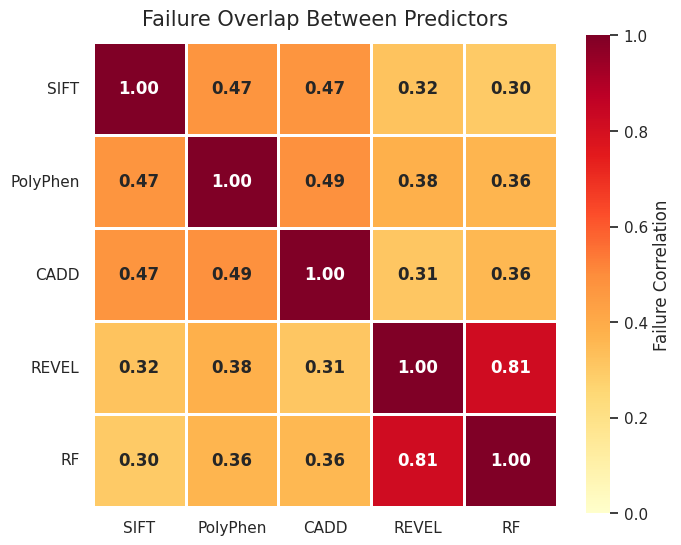

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

failure_overlap_cols = [
    "SIFT_failed",
    "PolyPhen_failed",
    "CADD_failed",
    "REVEL_failed",
    "RF_failed"
]

labels = ["SIFT", "PolyPhen", "CADD", "REVEL", "RF"]

failure_overlap = failure_df[failure_overlap_cols].astype(int).corr()
failure_overlap.index = labels
failure_overlap.columns = labels

plt.figure(figsize=(7, 6))

ax = sns.heatmap(
    failure_overlap,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Failure Correlation", "shrink": 0.9},
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title("Failure Overlap Between Predictors", fontsize=15, pad=12)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

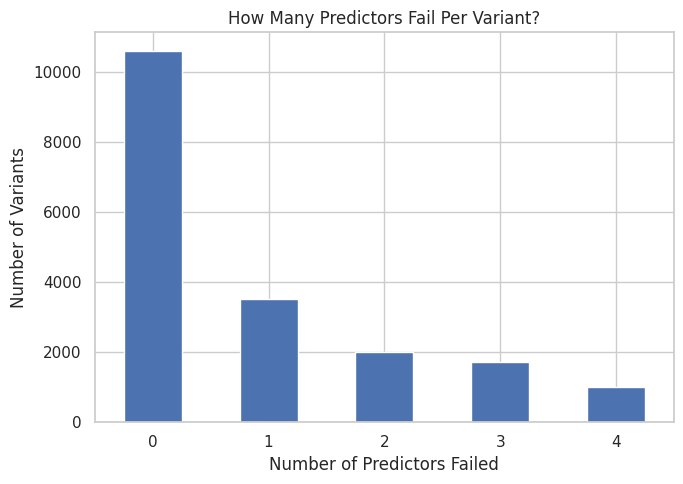

In [100]:
plt.figure(figsize=(7, 5))

failure_df["num_predictors_failed"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Number of Predictors Failed")
plt.ylabel("Number of Variants")
plt.title("How Many Predictors Fail Per Variant?")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

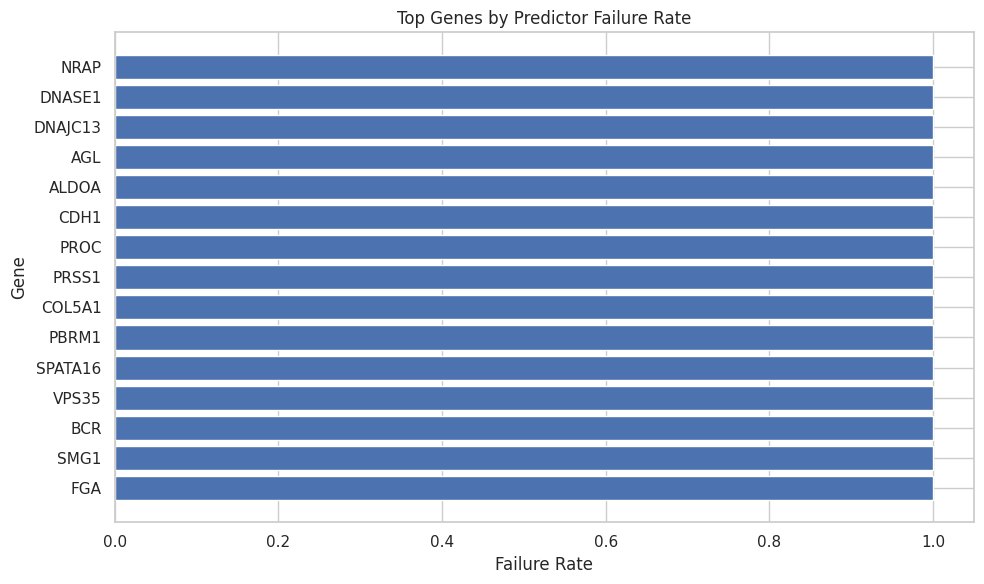

In [101]:
top_gene_failure = gene_failure.sort_values(
    "any_failure_rate",
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_gene_failure["Gene"],
    top_gene_failure["any_failure_rate"]
)

plt.xlabel("Failure Rate")
plt.ylabel("Gene")
plt.title("Top Genes by Predictor Failure Rate")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [102]:
from google.colab import files

top_genes = (
    gene_failure
    .sort_values(
        ["any_failure_rate", "avg_predictors_failed", "total_variants"],
        ascending=False
    )
    .head(10)
)
top_genes.to_csv("top_10_failure_genes.csv", index=False)
files.download("top_10_failure_genes.csv")
top_genes

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Gene,total_variants,avg_predictors_failed,variants_with_any_failure,any_failure_rate
4435,PROC,8,3.750000,8,1.0
4463,PRSS1,6,3.166667,6,1.0
1977,FGA,6,3.000000,6,1.0
1561,DNASE1,5,3.000000,5,1.0
2349,GRM8,5,2.800000,5,1.0
247,ALDOA,5,2.600000,5,1.0
1557,DNAJC13,7,2.571429,7,1.0
5265,SMG1,7,2.571429,7,1.0
2416,HBD,9,2.444444,9,1.0
567,BCR,5,2.400000,5,1.0


In [103]:
top_gene_names = top_genes["Gene"].tolist()

alphafold_variants = failure_df[
    failure_df["Gene"].isin(top_gene_names)
].copy()

alphafold_variants[[
    "Gene",
    "Entry",
    "AA_change",
    "Label",
    "Disease",
    "num_predictors_failed",
    "SIFT_failed",
    "PolyPhen_failed",
    "CADD_failed",
    "REVEL_failed"
]].head(20)

alphafold_variants.to_csv("alphafold_variants.csv", index=False)
files.download("alphafold_variants.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [104]:
# Core failure columns from your notebook
failure_cols = [
    "SIFT_failed",
    "PolyPhen_failed",
    "CADD_failed",
    "REVEL_failed"
]

# Make sure failures are boolean
for col in failure_cols:
    failure_df[col] = failure_df[col].astype(bool)

# Any failure among the four traditional predictors
failure_df["any_failure"] = failure_df[failure_cols].any(axis=1)

# Number of predictors that failed
failure_df["num_predictors_failed"] = failure_df[failure_cols].sum(axis=1)

failure_df[[
    "Gene",
    "AA_change",
    "Label",
    "SIFT_failed",
    "PolyPhen_failed",
    "CADD_failed",
    "REVEL_failed",
    "any_failure",
    "num_predictors_failed"
]].head()

,Gene,AA_change,Label,SIFT_failed,PolyPhen_failed,CADD_failed,REVEL_failed,any_failure,num_predictors_failed
60248,SH3BP4,p.Met155Thr,Benign,False,False,False,False,False,0
82901,SPEF2,p.Ala934Pro,Benign,False,False,False,False,False,0
103918,TJP2,p.Asp482Glu,Benign,False,False,False,False,False,0
88156,ARG1,p.Ile11Thr,Pathogenic,False,False,False,False,False,0
20308,HMBS,p.Glu86Val,Pathogenic,True,False,False,False,True,1


In [105]:
# Core failure columns from your notebook
failure_cols = [
    "SIFT_failed",
    "PolyPhen_failed",
    "CADD_failed",
    "REVEL_failed"
]

# Make sure failures are boolean
for col in failure_cols:
    failure_df[col] = failure_df[col].astype(bool)

# Any failure among the four traditional predictors
failure_df["any_failure"] = failure_df[failure_cols].any(axis=1)

# Number of predictors that failed
failure_df["num_predictors_failed"] = failure_df[failure_cols].sum(axis=1)

failure_df[[
    "Gene",
    "AA_change",
    "Label",
    "SIFT_failed",
    "PolyPhen_failed",
    "CADD_failed",
    "REVEL_failed",
    "any_failure",
    "num_predictors_failed"
]].head()

,Gene,AA_change,Label,SIFT_failed,PolyPhen_failed,CADD_failed,REVEL_failed,any_failure,num_predictors_failed
60248,SH3BP4,p.Met155Thr,Benign,False,False,False,False,False,0
82901,SPEF2,p.Ala934Pro,Benign,False,False,False,False,False,0
103918,TJP2,p.Asp482Glu,Benign,False,False,False,False,False,0
88156,ARG1,p.Ile11Thr,Pathogenic,False,False,False,False,False,0
20308,HMBS,p.Glu86Val,Pathogenic,True,False,False,False,True,1


In [106]:
gene_failure = (
    failure_df
    .groupby("Gene")
    .agg(
        total_variants=("Gene", "count"),
        variants_with_any_failure=("any_failure", "sum"),
        any_failure_rate=("any_failure", "mean"),
        avg_predictors_failed=("num_predictors_failed", "mean"),
        SIFT_failure_rate=("SIFT_failed", "mean"),
        PolyPhen_failure_rate=("PolyPhen_failed", "mean"),
        CADD_failure_rate=("CADD_failed", "mean"),
        REVEL_failure_rate=("REVEL_failed", "mean")
    )
    .reset_index()
)

# Avoid genes with tiny sample sizes
gene_failure_filtered = gene_failure[gene_failure["total_variants"] >= 5].copy()

top_genes = (
    gene_failure_filtered
    .sort_values(
        ["any_failure_rate", "avg_predictors_failed", "total_variants"],
        ascending=False
    )
    .head(10)
)

top_genes

,Gene,total_variants,variants_with_any_failure,any_failure_rate,avg_predictors_failed,SIFT_failure_rate,PolyPhen_failure_rate,CADD_failure_rate,REVEL_failure_rate
4435,PROC,8,8,1.0,3.750000,0.875000,1.000000,1.000000,0.875000
4463,PRSS1,6,6,1.0,3.166667,0.833333,1.000000,0.666667,0.666667
1977,FGA,6,6,1.0,3.000000,0.833333,0.666667,0.833333,0.666667
1561,DNASE1,5,5,1.0,3.000000,1.000000,0.800000,0.800000,0.400000
2349,GRM8,5,5,1.0,2.800000,0.600000,0.400000,1.000000,0.800000
247,ALDOA,5,5,1.0,2.600000,0.600000,0.600000,0.800000,0.600000
1557,DNAJC13,7,7,1.0,2.571429,0.428571,0.714286,1.000000,0.428571
5265,SMG1,7,7,1.0,2.571429,0.714286,0.714286,1.000000,0.142857
2416,HBD,9,9,1.0,2.444444,1.000000,0.444444,0.333333,0.666667
567,BCR,5,5,1.0,2.400000,0.600000,0.600000,1.000000,0.200000


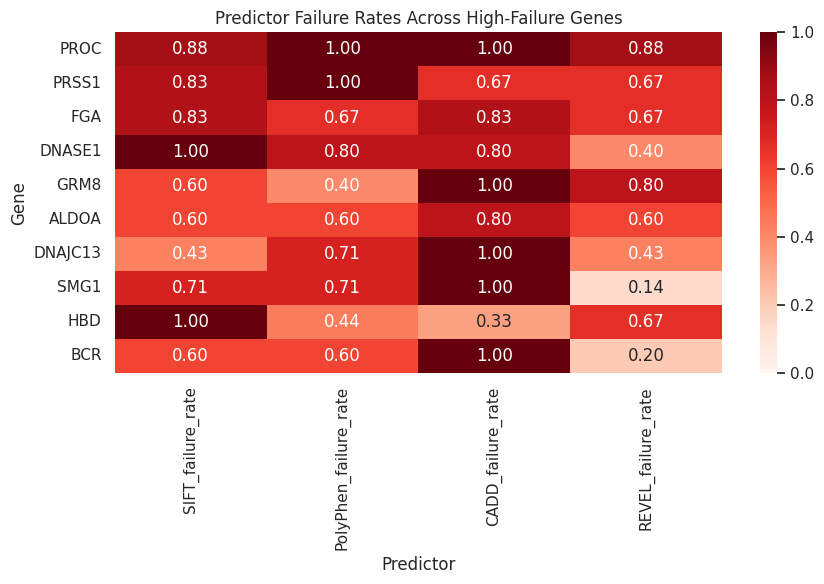

In [107]:
gene_heatmap = top_genes.set_index("Gene")[[
    "SIFT_failure_rate",
    "PolyPhen_failure_rate",
    "CADD_failure_rate",
    "REVEL_failure_rate"
]]

plt.figure(figsize=(9, 6))

sns.heatmap(
    gene_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0,
    vmax=1
)

plt.title("Predictor Failure Rates Across High-Failure Genes")
plt.xlabel("Predictor")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

In [108]:
import re

def extract_aa_substitution(aa_change):
    """
    Extracts amino acid substitution from strings like:
    p.Arg152His
    p.Gly162Ser
    """
    if pd.isna(aa_change):
        return pd.Series([np.nan, np.nan, np.nan, np.nan])

    match = re.match(r"p\.([A-Za-z]{3})(\d+)([A-Za-z]{3})", str(aa_change))

    if match:
        ref_aa = match.group(1)
        position = int(match.group(2))
        alt_aa = match.group(3)
        substitution = f"{ref_aa}->{alt_aa}"
        return pd.Series([ref_aa, position, alt_aa, substitution])

    return pd.Series([np.nan, np.nan, np.nan, np.nan])

failure_df[["ref_aa", "aa_position", "alt_aa", "aa_substitution"]] = (
    failure_df["AA_change"].apply(extract_aa_substitution)
)

failure_df[[
    "AA_change",
    "ref_aa",
    "aa_position",
    "alt_aa",
    "aa_substitution"
]].head()

,AA_change,ref_aa,aa_position,alt_aa,aa_substitution
60248,p.Met155Thr,Met,155,Thr,Met->Thr
82901,p.Ala934Pro,Ala,934,Pro,Ala->Pro
103918,p.Asp482Glu,Asp,482,Glu,Asp->Glu
88156,p.Ile11Thr,Ile,11,Thr,Ile->Thr
20308,p.Glu86Val,Glu,86,Val,Glu->Val


In [109]:
failed_variants = failure_df[failure_df["any_failure"] == True].copy()

top_failed_substitutions = (
    failed_variants["aa_substitution"]
    .value_counts()
    .reset_index()
)

top_failed_substitutions.columns = ["aa_substitution", "failure_count"]

top_failed_substitutions.head(15)

,aa_substitution,failure_count
0,Arg->Gln,330
1,Arg->His,300
2,Arg->Cys,280
3,Ala->Val,241
4,Ala->Thr,215
5,Pro->Leu,213
6,Glu->Lys,199
7,Arg->Trp,193
8,Val->Met,185
9,Val->Ile,162


In [110]:
failed_variants = failure_df[failure_df["any_failure"] == True].copy()

top_failed_substitutions = (
    failed_variants["aa_substitution"]
    .value_counts()
    .reset_index()
)

top_failed_substitutions.columns = ["aa_substitution", "failure_count"]

top_failed_substitutions.head(15)

,aa_substitution,failure_count
0,Arg->Gln,330
1,Arg->His,300
2,Arg->Cys,280
3,Ala->Val,241
4,Ala->Thr,215
5,Pro->Leu,213
6,Glu->Lys,199
7,Arg->Trp,193
8,Val->Met,185
9,Val->Ile,162


In [111]:
substitution_failure = (
    failure_df
    .dropna(subset=["aa_substitution"])
    .groupby("aa_substitution")
    .agg(
        total_variants=("aa_substitution", "count"),
        variants_with_any_failure=("any_failure", "sum"),
        failure_rate=("any_failure", "mean"),
        avg_predictors_failed=("num_predictors_failed", "mean")
    )
    .reset_index()
)

# Filter to substitutions with enough examples
substitution_failure_filtered = substitution_failure[
    substitution_failure["total_variants"] >= 5
].copy()

top_substitution_failures = (
    substitution_failure_filtered
    .sort_values(
        ["failure_rate", "avg_predictors_failed", "total_variants"],
        ascending=False
    )
    .head(15)
)

top_substitution_failures

,aa_substitution,total_variants,variants_with_any_failure,failure_rate,avg_predictors_failed
89,Lys->Ile,11,9,0.818182,2.000000
14,Arg->Met,9,7,0.777778,2.000000
25,Asn->Tyr,14,10,0.714286,1.571429
11,Arg->Ile,15,10,0.666667,1.533333
95,Met->Lys,27,18,0.666667,1.111111
114,Ser->Cys,85,56,0.658824,1.529412
44,Gln->Pro,60,38,0.633333,1.250000
61,His->Asp,37,23,0.621622,1.270270
107,Pro->His,58,36,0.620690,1.500000
50,Glu->Val,47,29,0.617021,1.361702


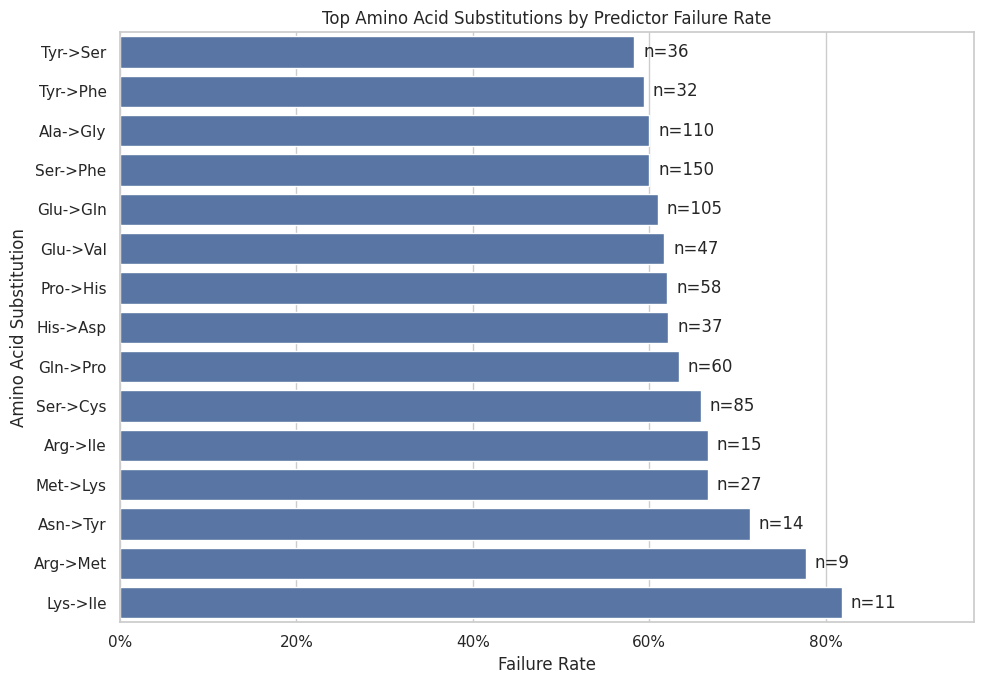

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = top_substitution_failures.sort_values("failure_rate", ascending=True)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=plot_df,
    x="failure_rate",
    y="aa_substitution"
)

plt.title("Top Amino Acid Substitutions by Predictor Failure Rate")
plt.xlabel("Failure Rate")
plt.ylabel("Amino Acid Substitution")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

# Add total variant count labels
for i, row in enumerate(plot_df.itertuples()):
    ax.text(
        row.failure_rate + 0.01,
        i,
        f"n={row.total_variants}",
        va="center"
    )

plt.xlim(0, min(1.1, plot_df["failure_rate"].max() + 0.15))
plt.tight_layout()
plt.show()

In [138]:
aa_properties = {
    "Gly": "small/nonpolar",
    "Ala": "small/nonpolar",
    "Val": "hydrophobic",
    "Leu": "hydrophobic",
    "Ile": "hydrophobic",
    "Met": "hydrophobic",
    "Phe": "aromatic",
    "Trp": "aromatic",
    "Tyr": "aromatic/polar",
    "Ser": "polar",
    "Thr": "polar",
    "Cys": "polar/sulfur",
    "Asn": "polar",
    "Gln": "polar",
    "Lys": "positive",
    "Arg": "positive",
    "His": "positive/aromatic",
    "Asp": "negative",
    "Glu": "negative",
    "Pro": "special/rigid"
}

failure_df["ref_aa_property"] = failure_df["ref_aa"].map(aa_properties)
failure_df["alt_aa_property"] = failure_df["alt_aa"].map(aa_properties)

failure_df["biochemical_change"] = (
    failure_df["ref_aa_property"] + " -> " + failure_df["alt_aa_property"]
)

biochemical_failure = (
    failure_df
    .dropna(subset=["biochemical_change"])
    .groupby("biochemical_change")
    .agg(
        total_variants=("biochemical_change", "count"),
        variants_with_any_failure=("any_failure", "sum"),
        failure_rate=("any_failure", "mean"),
        avg_predictors_failed=("num_predictors_failed", "mean")
    )
    .reset_index()
)

biochemical_failure_filtered = biochemical_failure[
    biochemical_failure["total_variants"] >= 10
].copy()

top_biochemical_failures = (
    biochemical_failure_filtered
    .sort_values(
        ["failure_rate", "avg_predictors_failed", "total_variants"],
        ascending=False
    )
    .head(15)
)

top_biochemical_failures

,biochemical_change,total_variants,variants_with_any_failure,failure_rate,avg_predictors_failed
31,polar -> polar/sulfur,85,56,0.658824,1.529412
52,positive/aromatic -> negative,37,23,0.621622,1.270270
67,special/rigid -> positive/aromatic,58,36,0.620690,1.500000
27,polar -> aromatic/polar,71,43,0.605634,1.169014
6,aromatic/polar -> aromatic,32,19,0.593750,1.281250
26,polar -> aromatic,168,97,0.577381,1.303571
20,negative -> hydrophobic,112,64,0.571429,1.178571
68,special/rigid -> small/nonpolar,138,78,0.565217,1.152174
62,small/nonpolar -> small/nonpolar,225,127,0.564444,1.213333
0,aromatic -> aromatic/polar,18,10,0.555556,1.055556


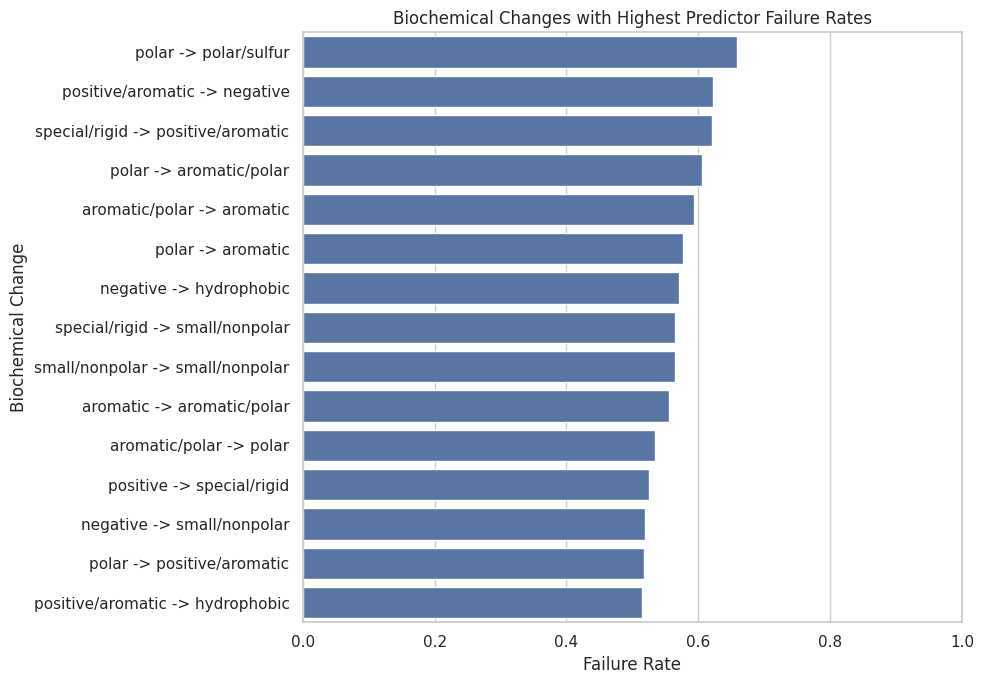

In [113]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_biochemical_failures,
    x="failure_rate",
    y="biochemical_change"
)

plt.title("Biochemical Changes with Highest Predictor Failure Rates")
plt.xlabel("Failure Rate")
plt.ylabel("Biochemical Change")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [114]:
disease_df = failure_df.copy()

# Remove missing or empty disease annotations
disease_df = disease_df[
    disease_df["Disease"].notna() &
    (disease_df["Disease"] != "-")
].copy()

disease_failure = (
    disease_df
    .groupby("Disease")
    .agg(
        total_variants=("Disease", "count"),
        variants_with_any_failure=("any_failure", "sum"),
        failure_rate=("any_failure", "mean"),
        avg_predictors_failed=("num_predictors_failed", "mean"),
        SIFT_failure_rate=("SIFT_failed", "mean"),
        PolyPhen_failure_rate=("PolyPhen_failed", "mean"),
        CADD_failure_rate=("CADD_failed", "mean"),
        REVEL_failure_rate=("REVEL_failed", "mean")
    )
    .reset_index()
)

# Filter to diseases with enough examples
disease_failure_filtered = disease_failure[
    disease_failure["total_variants"] >= 5
].copy()

top_disease_failures = (
    disease_failure_filtered
    .sort_values(
        ["failure_rate", "avg_predictors_failed", "total_variants"],
        ascending=False
    )
    .head(10)
)

top_disease_failures

,Disease,total_variants,variants_with_any_failure,failure_rate,avg_predictors_failed,SIFT_failure_rate,PolyPhen_failure_rate,CADD_failure_rate,REVEL_failure_rate
791,"Familial Mediterranean fever, autosomal recess...",13,12,0.923077,2.692308,0.538462,0.538462,0.846154,0.769231
97,"Amyotrophic lateral sclerosis 6, with or witho...",8,7,0.875000,1.375000,0.375000,0.750000,0.125000,0.125000
1735,Parkinson disease 8 (PARK8) [MIM:607060],13,11,0.846154,1.846154,0.538462,0.384615,0.307692,0.615385
1889,Retinitis pigmentosa 25 (RP25) [MIM:602772],6,5,0.833333,2.666667,0.500000,0.666667,0.666667,0.833333
1336,Medulloblastoma (MDB) [MIM:155255],6,5,0.833333,2.166667,0.500000,0.500000,0.333333,0.833333
950,Hereditary non-polyposis colorectal cancer 7 (...,5,4,0.800000,2.600000,0.600000,0.600000,0.600000,0.800000
1719,"Pancreatitis, hereditary (PCTT) [MIM:167800]",10,8,0.800000,2.300000,0.600000,0.700000,0.500000,0.500000
1193,Juvenile myoclonic epilepsy 1 (EJM1) [MIM:254770],5,4,0.800000,2.200000,0.400000,0.800000,0.200000,0.800000
1895,Retinitis pigmentosa 39 (RP39) [MIM:613809],5,4,0.800000,1.600000,0.600000,0.400000,0.400000,0.200000
60,"Albinism, oculocutaneous, 1B (OCA1B) [MIM:606952]",5,4,0.800000,1.200000,0.600000,0.400000,0.200000,0.000000


In [115]:
disease_df = failure_df.copy()

# Remove missing or empty disease annotations
disease_df = disease_df[
    disease_df["Disease"].notna() &
    (disease_df["Disease"] != "-")
].copy()

disease_failure = (
    disease_df
    .groupby("Disease")
    .agg(
        total_variants=("Disease", "count"),
        variants_with_any_failure=("any_failure", "sum"),
        failure_rate=("any_failure", "mean"),
        avg_predictors_failed=("num_predictors_failed", "mean"),
        SIFT_failure_rate=("SIFT_failed", "mean"),
        PolyPhen_failure_rate=("PolyPhen_failed", "mean"),
        CADD_failure_rate=("CADD_failed", "mean"),
        REVEL_failure_rate=("REVEL_failed", "mean")
    )
    .reset_index()
)

# Filter to diseases with enough examples
disease_failure_filtered = disease_failure[
    disease_failure["total_variants"] >= 5
].copy()

top_disease_failures = (
    disease_failure_filtered
    .sort_values(
        ["failure_rate", "avg_predictors_failed", "total_variants"],
        ascending=False
    )
    .head(10)
)

top_disease_failures

,Disease,total_variants,variants_with_any_failure,failure_rate,avg_predictors_failed,SIFT_failure_rate,PolyPhen_failure_rate,CADD_failure_rate,REVEL_failure_rate
791,"Familial Mediterranean fever, autosomal recess...",13,12,0.923077,2.692308,0.538462,0.538462,0.846154,0.769231
97,"Amyotrophic lateral sclerosis 6, with or witho...",8,7,0.875000,1.375000,0.375000,0.750000,0.125000,0.125000
1735,Parkinson disease 8 (PARK8) [MIM:607060],13,11,0.846154,1.846154,0.538462,0.384615,0.307692,0.615385
1889,Retinitis pigmentosa 25 (RP25) [MIM:602772],6,5,0.833333,2.666667,0.500000,0.666667,0.666667,0.833333
1336,Medulloblastoma (MDB) [MIM:155255],6,5,0.833333,2.166667,0.500000,0.500000,0.333333,0.833333
950,Hereditary non-polyposis colorectal cancer 7 (...,5,4,0.800000,2.600000,0.600000,0.600000,0.600000,0.800000
1719,"Pancreatitis, hereditary (PCTT) [MIM:167800]",10,8,0.800000,2.300000,0.600000,0.700000,0.500000,0.500000
1193,Juvenile myoclonic epilepsy 1 (EJM1) [MIM:254770],5,4,0.800000,2.200000,0.400000,0.800000,0.200000,0.800000
1895,Retinitis pigmentosa 39 (RP39) [MIM:613809],5,4,0.800000,1.600000,0.600000,0.400000,0.400000,0.200000
60,"Albinism, oculocutaneous, 1B (OCA1B) [MIM:606952]",5,4,0.800000,1.200000,0.600000,0.400000,0.200000,0.000000


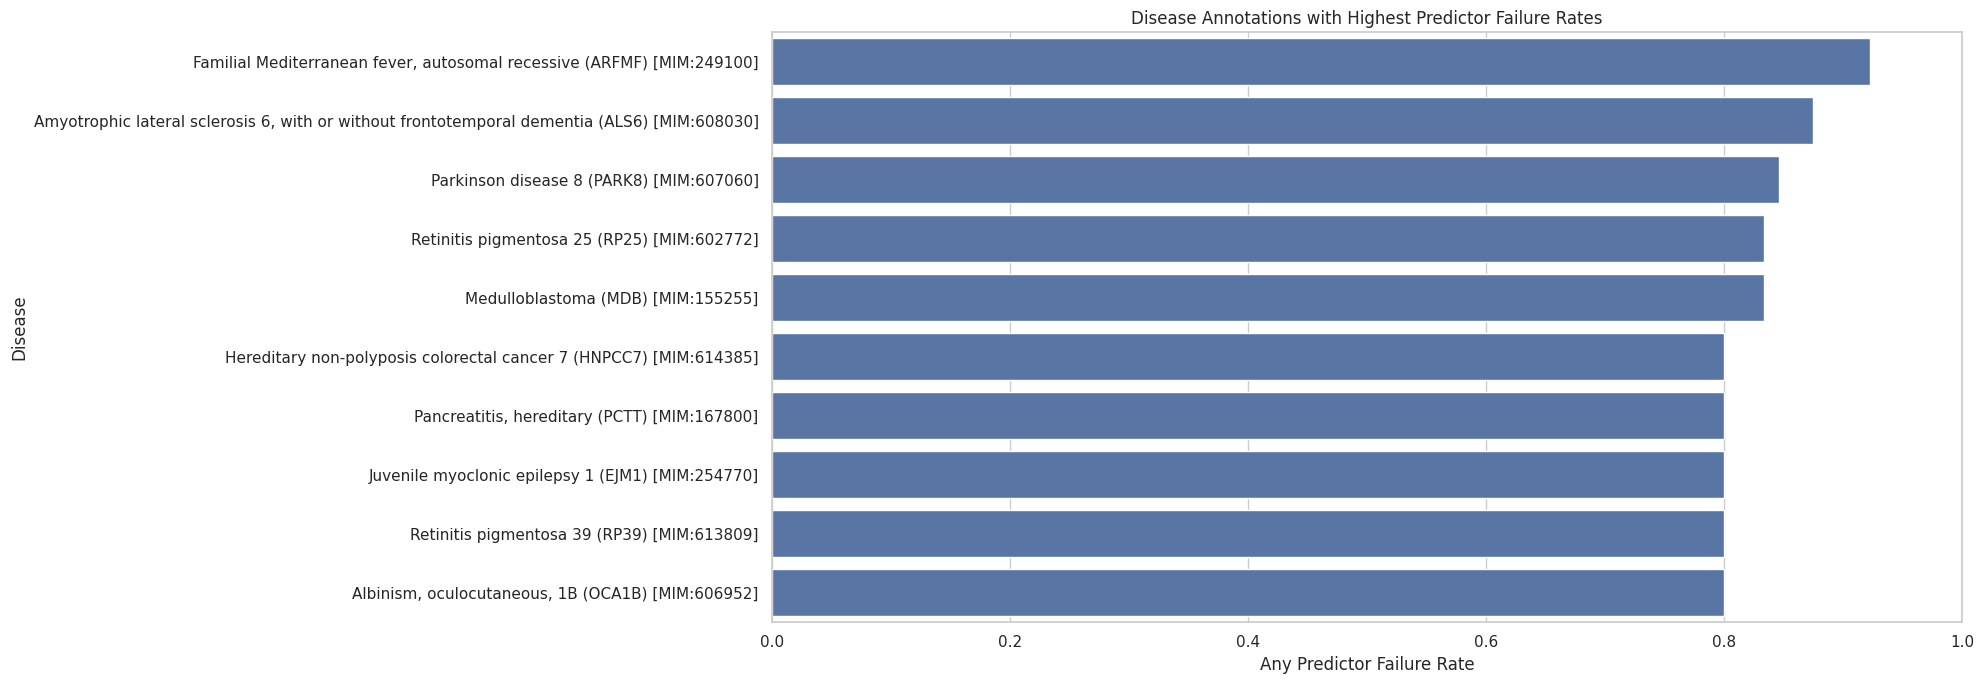

In [131]:
plt.figure(figsize=(20, 7))

sns.barplot(
    data=top_disease_failures,
    x="failure_rate",
    y="Disease"
)

plt.title("Disease Annotations with Highest Predictor Failure Rates")
plt.xlabel("Any Predictor Failure Rate")
plt.ylabel("Disease")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [117]:
prediction_cols = [
    "SIFT_pred_binary",
    "PolyPhen_pred_binary",
    "CADD_pred_binary",
    "REVEL_pred_binary"
]

# Number of predictors voting pathogenic
failure_df["num_pathogenic_votes"] = failure_df[prediction_cols].sum(axis=1)

# Disagreement means the four predictors do not all agree
# 0 votes = all benign
# 4 votes = all pathogenic
# 1, 2, 3 votes = disagreement
failure_df["predictor_disagreement"] = failure_df["num_pathogenic_votes"].between(1, 3)

failure_df[[
    "Gene",
    "AA_change",
    "Label",
    "num_pathogenic_votes",
    "predictor_disagreement",
    "any_failure",
    "num_predictors_failed"
]].head()

,Gene,AA_change,Label,num_pathogenic_votes,predictor_disagreement,any_failure,num_predictors_failed
60248,SH3BP4,p.Met155Thr,Benign,0,False,False,0
82901,SPEF2,p.Ala934Pro,Benign,0,False,False,0
103918,TJP2,p.Asp482Glu,Benign,0,False,False,0
88156,ARG1,p.Ile11Thr,Pathogenic,4,False,False,0
20308,HMBS,p.Glu86Val,Pathogenic,3,True,True,1


In [118]:
disagreement_summary = (
    failure_df
    .groupby("predictor_disagreement")
    .agg(
        total_variants=("predictor_disagreement", "count"),
        failure_rate=("any_failure", "mean"),
        avg_predictors_failed=("num_predictors_failed", "mean")
    )
    .reset_index()
)

disagreement_summary

,predictor_disagreement,total_variants,failure_rate,avg_predictors_failed
0,False,11615,0.087559,0.350237
1,True,7249,1.000000,1.753069


In [119]:
disagreement_summary = (
    failure_df
    .groupby("predictor_disagreement")
    .agg(
        total_variants=("predictor_disagreement", "count"),
        failure_rate=("any_failure", "mean"),
        avg_predictors_failed=("num_predictors_failed", "mean")
    )
    .reset_index()
)

disagreement_summary

,predictor_disagreement,total_variants,failure_rate,avg_predictors_failed
0,False,11615,0.087559,0.350237
1,True,7249,1.000000,1.753069


In [120]:
vote_pattern_summary = (
    failure_df
    .groupby("num_pathogenic_votes")
    .agg(
        total_variants=("num_pathogenic_votes", "count"),
        failure_rate=("any_failure", "mean"),
        avg_predictors_failed=("num_predictors_failed", "mean")
    )
    .reset_index()
)

vote_pattern_summary

,num_pathogenic_votes,total_variants,failure_rate,avg_predictors_failed
0,0,5594,0.041294,0.165177
1,1,2675,1.000000,1.257196
2,2,2005,1.000000,2.000000
3,3,2569,1.000000,2.076684
4,4,6021,0.130543,0.522172


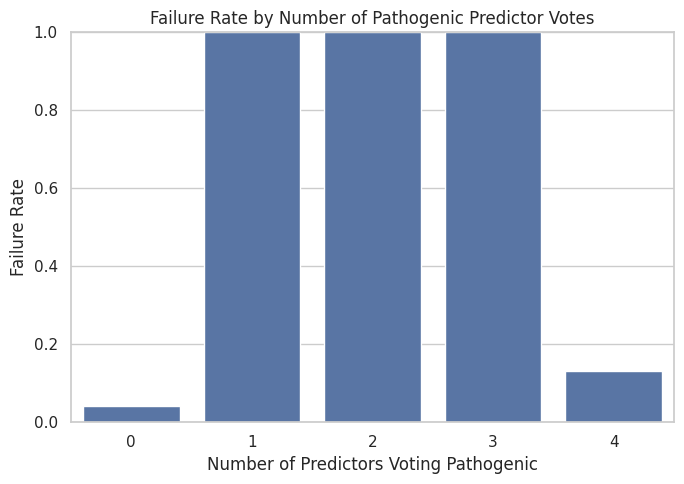

In [121]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=vote_pattern_summary,
    x="num_pathogenic_votes",
    y="failure_rate"
)

plt.title("Failure Rate by Number of Pathogenic Predictor Votes")
plt.xlabel("Number of Predictors Voting Pathogenic")
plt.ylabel("Failure Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [122]:
# Distance from threshold
# Smaller distance means closer to the decision boundary

failure_df["SIFT_boundary_distance"] = abs(failure_df["SIFT_score_clean"] - 0.05)
failure_df["PolyPhen_boundary_distance"] = abs(failure_df["PolyPhen_score_clean"] - 0.909)
failure_df["CADD_boundary_distance"] = abs(failure_df["CADD_phred_clean"] - 20)
failure_df["REVEL_boundary_distance"] = abs(failure_df["REVEL_score_clean"] - 0.5)

failure_df[[
    "SIFT_score_clean",
    "SIFT_boundary_distance",
    "PolyPhen_score_clean",
    "PolyPhen_boundary_distance",
    "CADD_phred_clean",
    "CADD_boundary_distance",
    "REVEL_score_clean",
    "REVEL_boundary_distance"
]].head()

,SIFT_score_clean,SIFT_boundary_distance,PolyPhen_score_clean,PolyPhen_boundary_distance,CADD_phred_clean,CADD_boundary_distance,REVEL_score_clean,REVEL_boundary_distance
60248,0.597,0.547,0.000,0.909,0.984,19.016,0.032,0.468
82901,0.730,0.680,0.000,0.909,0.017,19.983,0.013,0.487
103918,1.000,0.950,0.000,0.909,3.936,16.064,0.014,0.486
88156,0.001,0.049,0.994,0.085,25.000,5.000,0.807,0.307
20308,0.199,0.149,0.996,0.087,27.900,7.900,0.899,0.399


In [123]:
boundary_comparison = pd.DataFrame({
    "Predictor": ["SIFT", "PolyPhen-2", "CADD PHRED", "REVEL"],
    "Mean Distance When Correct": [
        failure_df.loc[failure_df["SIFT_failed"] == False, "SIFT_boundary_distance"].mean(),
        failure_df.loc[failure_df["PolyPhen_failed"] == False, "PolyPhen_boundary_distance"].mean(),
        failure_df.loc[failure_df["CADD_failed"] == False, "CADD_boundary_distance"].mean(),
        failure_df.loc[failure_df["REVEL_failed"] == False, "REVEL_boundary_distance"].mean()
    ],
    "Mean Distance When Incorrect": [
        failure_df.loc[failure_df["SIFT_failed"] == True, "SIFT_boundary_distance"].mean(),
        failure_df.loc[failure_df["PolyPhen_failed"] == True, "PolyPhen_boundary_distance"].mean(),
        failure_df.loc[failure_df["CADD_failed"] == True, "CADD_boundary_distance"].mean(),
        failure_df.loc[failure_df["REVEL_failed"] == True, "REVEL_boundary_distance"].mean()
    ]
})

boundary_comparison

,Predictor,Mean Distance When Correct,Mean Distance When Incorrect
0,SIFT,0.212991,0.075748
1,PolyPhen-2,0.474604,0.228976
2,CADD PHRED,9.174503,4.536845
3,REVEL,0.353365,0.187960


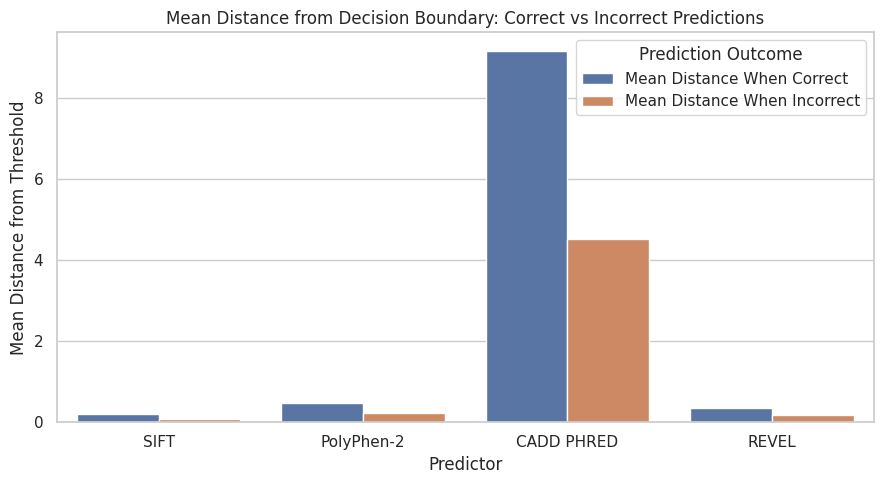

In [124]:
boundary_melted = boundary_comparison.melt(
    id_vars="Predictor",
    var_name="Prediction Outcome",
    value_name="Mean Boundary Distance"
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=boundary_melted,
    x="Predictor",
    y="Mean Boundary Distance",
    hue="Prediction Outcome"
)

plt.title("Mean Distance from Decision Boundary: Correct vs Incorrect Predictions")
plt.ylabel("Mean Distance from Threshold")
plt.xlabel("Predictor")
plt.tight_layout()
plt.show()

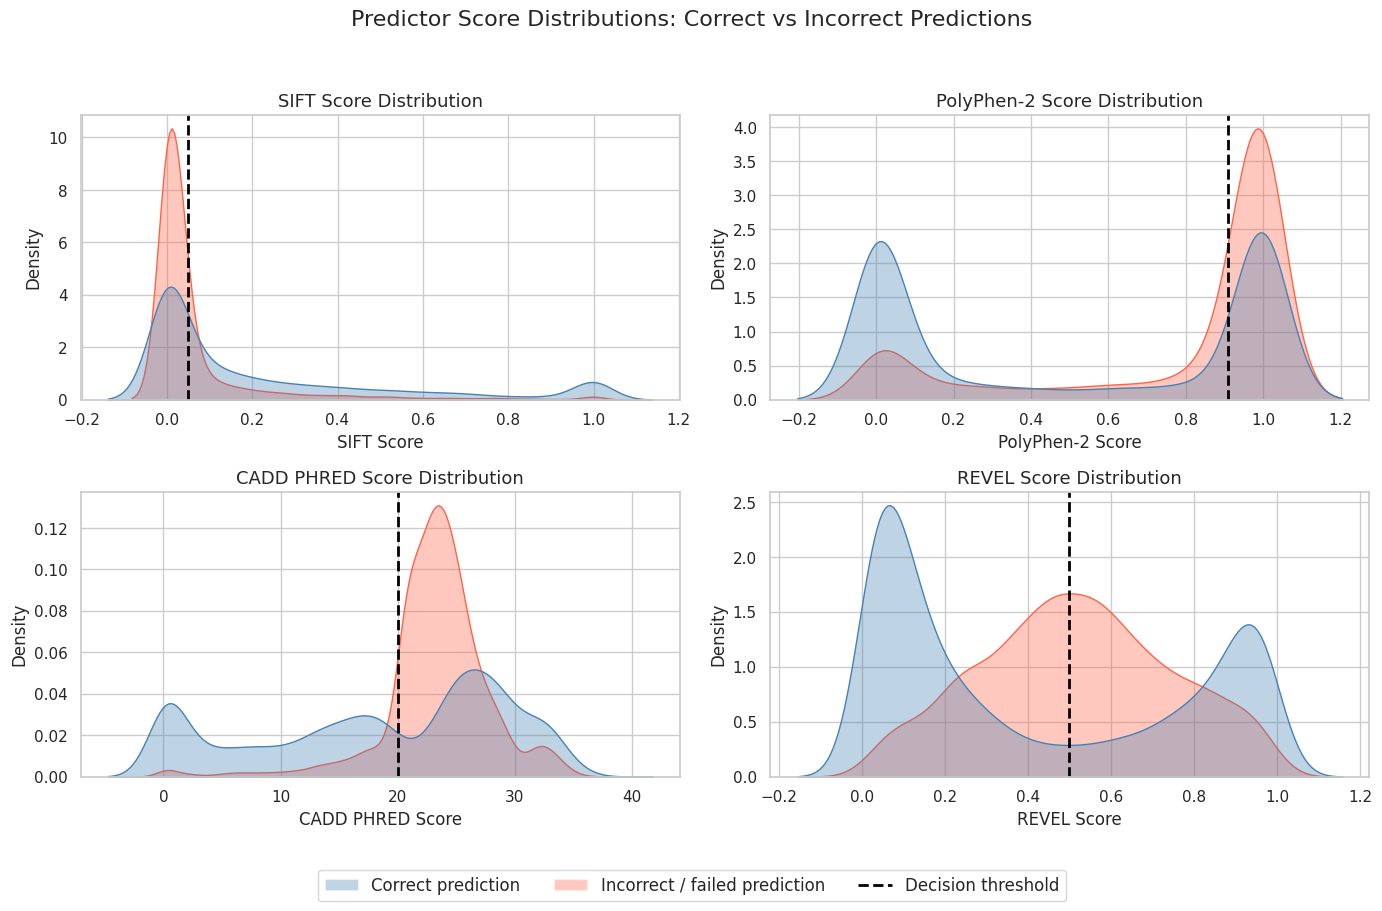

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

predictor_info = {
    "SIFT": {
        "score_col": "SIFT_score_clean",
        "failure_col": "SIFT_failed",
        "threshold": 0.05
    },
    "PolyPhen-2": {
        "score_col": "PolyPhen_score_clean",
        "failure_col": "PolyPhen_failed",
        "threshold": 0.909
    },
    "CADD PHRED": {
        "score_col": "CADD_phred_clean",
        "failure_col": "CADD_failed",
        "threshold": 20
    },
    "REVEL": {
        "score_col": "REVEL_score_clean",
        "failure_col": "REVEL_failed",
        "threshold": 0.5
    }
}

status_colors = {
    False: "steelblue",
    True: "tomato"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (predictor, info) in zip(axes, predictor_info.items()):

    plot_df = failure_df[
        [info["score_col"], info["failure_col"]]
    ].dropna().copy()

    sns.kdeplot(
        data=plot_df,
        x=info["score_col"],
        hue=info["failure_col"],
        fill=True,
        common_norm=False,
        alpha=0.35,
        palette=status_colors,
        ax=ax,
        legend=False
    )

    ax.axvline(
        info["threshold"],
        linestyle="--",
        color="black",
        linewidth=2
    )

    ax.set_title(f"{predictor} Score Distribution", fontsize=13)
    ax.set_xlabel(f"{predictor} Score")
    ax.set_ylabel("Density")

# Shared legend below the graph
legend_elements = [
    Patch(facecolor="steelblue", alpha=0.35, label="Correct prediction"),
    Patch(facecolor="tomato", alpha=0.35, label="Incorrect / failed prediction"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="Decision threshold")
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    fontsize=12,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    "Predictor Score Distributions: Correct vs Incorrect Predictions",
    fontsize=16,
    y=0.98
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [127]:
summary_results = {
    "Total variants in test-set failure_df": len(failure_df),
    "Variants with any predictor failure": failure_df["any_failure"].sum(),
    "Any failure rate": failure_df["any_failure"].mean(),
    "Mean predictors failed per variant": failure_df["num_predictors_failed"].mean(),
    "Predictor disagreement rate": failure_df["predictor_disagreement"].mean(),
    "Failure rate among disagreement cases": failure_df.loc[
        failure_df["predictor_disagreement"],
        "any_failure"
    ].mean(),
    "Failure rate among agreement cases": failure_df.loc[
        ~failure_df["predictor_disagreement"],
        "any_failure"
    ].mean()
}

summary_df = pd.DataFrame(
    list(summary_results.items()),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Total variants in test-set failure_df,18864.000000
1,Variants with any predictor failure,8266.000000
2,Any failure rate,0.438189
3,Mean predictors failed per variant,0.889313
4,Predictor disagreement rate,0.384277
5,Failure rate among disagreement cases,1.000000
6,Failure rate among agreement cases,0.087559


In [128]:
gene_failure.to_csv("gene_failure_analysis.csv", index=False)
top_genes.to_csv("top_genes_phase4.csv", index=False)

substitution_failure.to_csv("amino_acid_substitution_failure_analysis.csv", index=False)
top_substitution_failures.to_csv("top_amino_acid_substitution_failures.csv", index=False)

biochemical_failure.to_csv("biochemical_failure_analysis.csv", index=False)
top_biochemical_failures.to_csv("top_biochemical_failures.csv", index=False)

disease_failure.to_csv("disease_failure_analysis.csv", index=False)
top_disease_failures.to_csv("top_disease_failures.csv", index=False)

disagreement_summary.to_csv("predictor_disagreement_summary.csv", index=False)
vote_pattern_summary.to_csv("predictor_vote_pattern_summary.csv", index=False)

boundary_comparison.to_csv("confidence_boundary_analysis.csv", index=False)

summary_df.to_csv("phase_4_5_6_summary.csv", index=False)

print("Saved all Phase 4–6 analysis CSV files.")

Saved all Phase 4–6 analysis CSV files.


In [129]:
from google.colab import files

output_files = [
    "gene_failure_analysis.csv",
    "top_genes_phase4.csv",
    "amino_acid_substitution_failure_analysis.csv",
    "top_amino_acid_substitution_failures.csv",
    "biochemical_failure_analysis.csv",
    "top_biochemical_failures.csv",
    "disease_failure_analysis.csv",
    "top_disease_failures.csv",
    "predictor_disagreement_summary.csv",
    "predictor_vote_pattern_summary.csv",
    "confidence_boundary_analysis.csv",
    "phase_4_5_6_summary.csv"
]

for file in output_files:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [132]:
for pred_col, predictor in [
    ("SIFT_pred_binary", "SIFT"),
    ("PolyPhen_pred_binary", "PolyPhen"),
    ("CADD_pred_binary", "CADD"),
    ("REVEL_pred_binary", "REVEL")
]:
    failure_df[f"{predictor}_false_positive"] = (
        (failure_df["y"] == 0) & (failure_df[pred_col] == 1)
    )

    failure_df[f"{predictor}_false_negative"] = (
        (failure_df["y"] == 1) & (failure_df[pred_col] == 0)
    )

fp_fn_summary = pd.DataFrame({
    "Predictor": ["SIFT", "PolyPhen", "CADD", "REVEL"],
    "False Positives": [
        failure_df["SIFT_false_positive"].sum(),
        failure_df["PolyPhen_false_positive"].sum(),
        failure_df["CADD_false_positive"].sum(),
        failure_df["REVEL_false_positive"].sum()
    ],
    "False Negatives": [
        failure_df["SIFT_false_negative"].sum(),
        failure_df["PolyPhen_false_negative"].sum(),
        failure_df["CADD_false_negative"].sum(),
        failure_df["REVEL_false_negative"].sum()
    ]
})

fp_fn_summary

,Predictor,False Positives,False Negatives
0,SIFT,4264,1142
1,PolyPhen,2991,1467
2,CADD,4181,496
3,REVEL,1158,1077


In [136]:
top_genes_min20 = (
    gene_failure[gene_failure["total_variants"] >= 20]
    .sort_values(
        ["any_failure_rate", "avg_predictors_failed", "total_variants"],
        ascending=False
    )
    .head(15)
)

top_genes_min20

,Gene,total_variants,variants_with_any_failure,any_failure_rate,avg_predictors_failed,SIFT_failure_rate,PolyPhen_failure_rate,CADD_failure_rate,REVEL_failure_rate
2415,HBB,115,112,0.973913,2.965217,0.895652,0.478261,0.678261,0.913043
7,ABCA1,25,19,0.760000,2.160000,0.480000,0.400000,0.680000,0.600000
232,ALB,21,15,0.714286,1.619048,0.285714,0.333333,0.666667,0.333333
5956,TTN,74,52,0.702703,1.648649,0.432432,0.500000,0.554054,0.162162
619,BRCA1,40,28,0.700000,1.450000,0.525000,0.325000,0.225000,0.375000
135,ADGRD1,27,17,0.629630,1.370370,0.444444,0.370370,0.518519,0.037037
620,BRCA2,50,31,0.620000,1.520000,0.560000,0.360000,0.280000,0.320000
2802,KCNH2,49,30,0.612245,1.061224,0.285714,0.510204,0.163265,0.102041
4207,PKD1,28,17,0.607143,1.321429,0.357143,0.392857,0.392857,0.178571
4191,PIK3CA,33,20,0.606061,1.272727,0.363636,0.393939,0.000000,0.515152


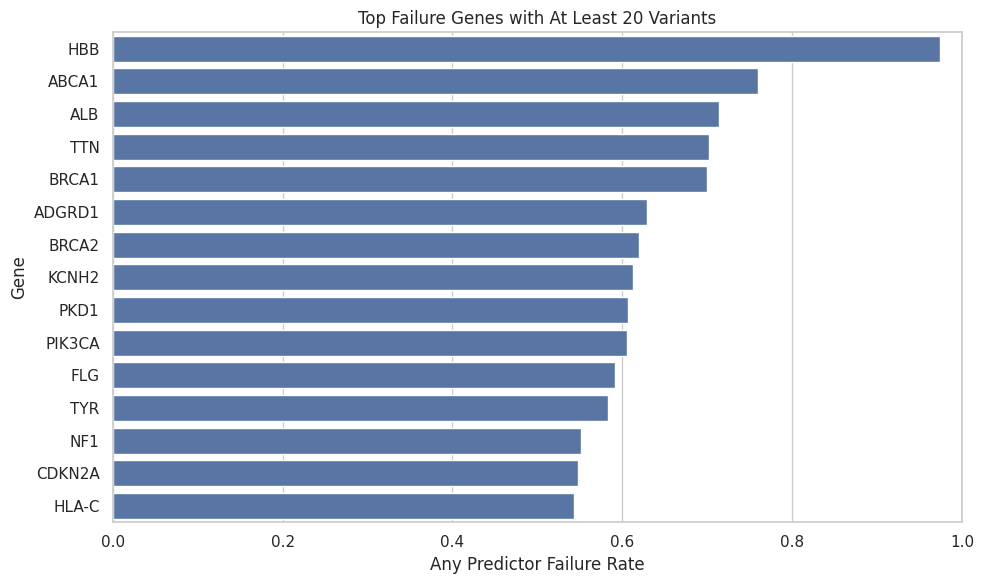

In [134]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_genes_min20,
    x="any_failure_rate",
    y="Gene"
)

plt.title("Top Failure Genes with At Least 20 Variants")
plt.xlabel("Any Predictor Failure Rate")
plt.ylabel("Gene")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()